# Digit Recognition — CNN

This notebook trains a **Convolutional Neural Network (CNN)** to recognize printed digits (1–9) from extracted Sudoku cell images.

**Pipeline:**
1. Download and load the Chars74K `EnglishFnt` digits only
2. Preprocess and augment the training images
3. Train a stronger CNN with batch normalisation, AdamW, and early stopping
4. Evaluate on all Sudoku puzzles as out-of-domain real-world data
5. Export trained model to `models/digit_cnn.pth` and helper module `cnn_model.py`


In [1]:
__all__ = ["create_gaussian_kernel", "linear_filter", "median_filter",
           "create_histogram", "find_otsu_threshold", "perform_global_threshold",
           "apply_adaptive_threshold", "harris_corners", "order_points", "find_arc_length",
           "find_area", "is_cell_empty", "approximate_polygon", "extract_sudoku_cells", "rotate_board",
           "warp_perspective_inverse", "warp_perspective_forward"]

import math
import numpy as np
from numba import njit

def create_gaussian_kernel(L, sigma=None):
    """
    Creates a 2D Gaussian kernel used for image smoothing.
    The kernel values are computed using the Gaussian distribution formula
    and normalized so that all values sum to 1.
    Args
        L (int): Kernel size (must be a positive odd integer).
        sigma (float): Standard deviation of the Gaussian distribution. Defaults to L/6 if  is not provided
    Returns:
        numpy array: Normalized 2D Gaussian kernel of shape (L, L).
    """
    if L % 2 == 0 or L <= 0:
        raise ValueError("Kernel size must be an odd integer and greater than 0")
    if sigma is None:
        sigma = L / 6
    midpoint = L // 2
    kernel = [[0 for _ in range(L)] for _ in range(L)]
    total = 0
    for i in range(L):
        for j in range(L):
            y = (i - midpoint)
            x = (j - midpoint)
            value = (1/(2*math.pi*sigma**2)) * math.exp(-(x**2 + y**2)/(2*sigma**2))
            kernel[i][j] = value
            total += value
    for i in range(L):
        for j in range(L):
            kernel[i][j] /= total # Normalization
    return np.array(kernel)


@njit
def _apply_kernel(padded_image, kernel, padding_size):
    """Helper function for performing kernel operations for linear_filter function."""
    N, M = padded_image.shape
    filtered_image = np.zeros_like(padded_image)

    for i in range(padding_size, N - padding_size):
        for j in range(padding_size, M - padding_size):
            # Explicit slicing for Numba compatibility
            image_window = padded_image[i-padding_size : i+padding_size+1, j-padding_size : j+padding_size+1]
            newPixel = np.sum(image_window * kernel)
            filtered_image[i, j] = newPixel
    return filtered_image


def linear_filter(image, kernel, is_clipped=True):
    """
    Applies a linear filter to an image using convolution with the given kernel.
    Supports both grayscale and RGB/BGR images. For RGB images, the kernel
    is applied independently to each channel.
    Args:
        image (numpy array): Grayscale or RGB/BGR image.
        kernel (numpy array): 2D convolution kernel (must be square with odd dimensions).
        is_clipped (bool): If True, output is clipped to [0, 255] as uint8.
                           Set to False to preserve raw float32 values for gradient operations.
    Returns:
        numpy array: Filtered image of the same shape as input, or None if kernel is invalid.
    """
    def _convolution(image, kernel):
        """Helper function for performing convolution for apply_kernel function."""
        L = len(kernel)
        padding_size = (L - 1) // 2
        padded_image = np.pad(image, pad_width=padding_size, mode='edge').astype(np.float32)
        filtered_image = _apply_kernel(padded_image, kernel, padding_size)
        filtered_image = filtered_image[padding_size: -padding_size, padding_size: -padding_size]
        if is_clipped:
            return np.clip(filtered_image, 0, 255).astype(np.uint8)
        else:
            return filtered_image # Returns raw float32 values

    if len(kernel) % 2 == 0 or len(kernel) <= 0:
        raise ValueError("Kernel size must be an odd integer and greater than 0")
    if len(image.shape) == 3: # RGB/BGR images
        channels = [_convolution(image[:, :, i], kernel) for i in range(3)]
        return np.dstack(channels)
    else: # Grayscale images
        return _convolution(image, kernel)


@njit
def _apply_median_kernel(padded_image, L, padding_size):
    """Helper function for performing kernel operations for median_filter function."""
    N, M = padded_image.shape
    im_filtered = np.zeros_like(padded_image)
    for i in range(padding_size, N-padding_size):
        for j in range(padding_size, M-padding_size):
            median = np.median(padded_image[i-padding_size : i+padding_size+1, j-padding_size : j+padding_size+1])
            im_filtered[i, j] = median
    return im_filtered


def median_filter(image, L):
    """
    Applies a median filter to a grayscale image.
    Replaces each pixel with the median value in its surrounding L x L neighborhood.
    Effective at removing salt-and-pepper noise while preserving edges.
    Args:
        image (numpy array): Grayscale image.
        L (int): Kernel size (must be a positive odd integer).
    Returns:
        numpy array: Filtered grayscale image of the same shape, or None if L is invalid.
    """
    if L % 2 == 0 or L <= 0:
        raise ValueError("Kernel size must be an odd integer and greater than 0")
    if len(image.shape) == 2: # only grayscale images
        padding_size = (L-1) // 2
        padded_image = np.pad(image, pad_width=padding_size, mode='edge').astype(np.float32)
        filtered_image = _apply_median_kernel(padded_image, L, padding_size)
        return np.clip(filtered_image[padding_size: -padding_size, padding_size: -padding_size], 0, 255).astype(np.uint8)


def create_histogram(image, bin_size, is_normalized):
    """
    Creates an intensity histogram of a grayscale image.
    Args:
        image (numpy array): Grayscale image.
        bin_size (int): Number of intensity levels (typically 256 for uint8 images).
        is_normalized (bool): If True, histogram values represent frequency ratios instead of counts.
    Returns:
        tuple: (hist, bin) where hist is a list of counts/frequencies and bin is a list of intensity levels.
    """
    N,M = image.shape
    hist = [0 for i in range(bin_size)]
    bin = [i for i in range(bin_size)]
    for i in range(len(image)):
        for j in range(len(image[i])):
            if is_normalized:
                hist[image[i][j]] += (1 / (N*M))
            else:
                hist[image[i][j]] += 1
    return hist, bin


def find_otsu_threshold(hist_norm):
    """
    Finds the optimal global threshold of an image using Otsu's algorithm.
    Iterates over all possible thresholds and selects the one that maximizes
    the between-class variance of the two resulting pixel groups.
    Args:
        hist_norm (list): Normalized intensity histogram (output of create_histogram with is_normalized=True).
    Returns:
        int: Optimal threshold value in range [0, 255].
    """
    def _calculate_between_class_variance(hist_norm, T):
        # Todo: This function needs to be optimized in terms of time complexity
        P1, sum1 = 0, 0
        P2, sum2 = 0, 0
        for i in range(len(hist_norm)):
            if i < T:
                sum1 += (i * hist_norm[i])
                P1 += hist_norm[i]
            else:
                sum2 += (i * hist_norm[i])
                P2 += hist_norm[i]
        if P1 == 0 or P2 == 0:
            return 0
        m1 = sum1 / P1
        m2 = sum2 / P2
        variance = (P1*P2) * (m1-m2)**2
        return variance

    max_variance = 0
    best_threshold = 0
    for i in range(len(hist_norm)):
        variance = _calculate_between_class_variance(hist_norm, i) # Todo: This line needs to be optimized
        if variance > max_variance:
            max_variance = variance
            best_threshold = i
    return best_threshold

def perform_global_threshold(image, threshold):
    """
    Applies global thresholding to a grayscale image.
    Pixels with intensity above the threshold are set to 255, all others to 0.
    Args:
        image (numpy array): Grayscale image.
        threshold (int): Intensity threshold value in range [0, 255].
    Returns:
        numpy array: Binary image of the same shape as input.
    """
    N, M = image.shape
    image_threshold = np.zeros((N, M))
    for i in range(len(image_threshold)):
        for j in range(len(image_threshold[i])):
            if image[i][j] > threshold:
                image_threshold[i][j] = 255
            else:
                image_threshold[i][j] = 0
    return image_threshold

@njit
def _apply_threshold_kernel(padded_image, kernel, padding_size, C, is_inverse):
    """Helper function for performing kernel operations for adaptive thresholding."""
    N, M = padded_image.shape
    threshold_image = np.zeros((N, M), dtype=np.uint8)

    for i in range(padding_size, N - padding_size):
        for j in range(padding_size, M - padding_size):
            # Explicit slicing for Numba compatibility
            image_window = padded_image[i-padding_size : i+padding_size+1, j-padding_size : j+padding_size+1]
            threshold = np.sum(image_window * kernel) - C
            if is_inverse:
                if padded_image[i,j] < threshold:
                    threshold_image[i,j] = 255 # Make ink white (for findContours)
                else:
                    threshold_image[i,j] = 0   # Make paper black
            else:
                if padded_image[i,j] >= threshold:
                    threshold_image[i,j] = 255
                else:
                    threshold_image[i,j] = 0
    return threshold_image


def apply_adaptive_threshold(image, L, C=0, is_inverse=False):
    """
    Applies adaptive Gaussian thresholding to a grayscale image.
    Unlike global thresholding, the threshold is computed locally for each pixel
    using a weighted Gaussian average of its L x L neighborhood, minus a constant C.
    This handles uneven illumination across the image.
    Args:
        image (numpy array): Grayscale image.
        L (int): Kernel size for the local neighborhood (must be a positive odd integer).
        C (float): Constant subtracted from the local mean threshold. Defaults to 0.
        is_inverse (bool): If True, pixels below the threshold are set to 255 (ink white on black paper).
                        Useful for contour detection downstream.
    Returns:
        numpy array: Binary thresholded image of the same shape, or None if L is invalid.
    """
    if L % 2 == 0 or L <= 0:
        raise ValueError("Kernel size must be an odd integer and greater than 0")
    if len(image.shape) != 2: # RGB images give error
        raise ValueError("Image must be in grayscale to apply thresholding")
    kernel = create_gaussian_kernel(L, L/6)
    padding_size = (L - 1) // 2
    padded_image = np.pad(image, pad_width=padding_size, mode='edge').astype(np.float32)
    threshold_image = _apply_threshold_kernel(padded_image, kernel, padding_size, C, is_inverse)
    threshold_image = threshold_image[padding_size: -padding_size, padding_size: -padding_size]
    return threshold_image


@njit
def _compute_harris_response(I_x, I_y, window, window_size, padding_size, k, H, W):
    """ Helper function for Harris Corner algorithm"""
    response = np.zeros((H, W))
    for i in range(padding_size, H-padding_size):
        for j in range(padding_size, W-padding_size):
            I_x_squared = np.square(I_x[i-padding_size: i+padding_size+1, j-padding_size: j+padding_size+1])
            I_y_squared = np.square(I_y[i-padding_size: i+padding_size+1, j-padding_size: j+padding_size+1])
            I_x_y = np.multiply(I_x[i-padding_size: i+padding_size+1, j-padding_size: j+padding_size+1], I_y[i-padding_size: i+padding_size+1, j-padding_size: j+padding_size+1])

            for a in range(window_size):
                for b in range(window_size):
                    I_x_squared[a,b] = window[a,b] * I_x_squared[a,b]
                    I_y_squared[a,b] = window[a,b] * I_y_squared[a,b]
                    I_x_y[a,b] = window[a,b] * I_x_y[a,b]

            sum_I_x_squared = np.sum(I_x_squared)
            sum_I_y_squared = np.sum(I_y_squared)
            sum_I_x_I_y = np.sum(I_x_y)
            determinant = sum_I_x_squared * sum_I_y_squared - sum_I_x_I_y * sum_I_x_I_y
            trace = sum_I_x_squared + sum_I_y_squared
            response[i][j] = determinant - (k * trace * trace)
    return response


def harris_corners(img, window_size=3, k=0.04):
    """
    Detects corners in a grayscale image using the Harris Corner Detection algorithm.
    Computes the Harris response at each pixel by applying Sobel gradients and a
    sliding window to estimate local structure. High positive response values indicate corners.
    Args:
        img (numpy array): Grayscale image.
        window_size (int): Size of the sliding window used to accumulate gradient information.
        k (float): Harris sensitivity parameter. Typical values are in range [0.04, 0.06].
    Returns:
        numpy array: Harris response map of the same shape as input (float values).
    """
    H, W = img.shape
    window = np.ones((window_size, window_size))
    padding_size = (window_size-1) // 2

    # 1. Compute x and y derivatives (I_x, I_y) of an image
    kernel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    kernel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
    I_x = linear_filter(img, kernel_x, False)
    I_y = linear_filter(img, kernel_y, False)

    response = _compute_harris_response(I_x, I_y, window, window_size, padding_size, k, H, W)
    return response


def order_points(pts):
    """
    Orders 4 corner points into a consistent format for perspective transformation.
    The ordering is determined by coordinate sums and differences, making it
    robust to the order in which the points were originally detected.
    Args:
        pts (numpy array): Array of 4 points of shape (4, 2).
    Returns:
        numpy array: Ordered points of shape (4, 2) in the format
                     [top-left, top-right, bottom-right, bottom-left].
    """
    rect = np.zeros((4, 2), dtype="float32")

    # The top-left point will have the smallest sum, whereas
    # the bottom-right point will have the largest sum
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]

    # Now, compute the difference between the points, the
    # top-right point will have the smallest difference,
    # whereas the bottom-left will have the largest difference
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]

    return rect

@njit
def find_arc_length(coordinates, is_closed=False):
    """
    Computes the total arc length of a polyline defined by a sequence of 2D points.
    Sums the Euclidean distances between consecutive points. If the shape is closed,
    the distance from the last point back to the first is also included.
    Args:
        coordinates (numpy array): Array of [x, y] values of shape (N, 2).
        is_closed (bool): If True, includes the closing segment from last point to first.
    Returns:
        float: Total arc length of the polyline.
    """
    distance = 0
    (prev_x, prev_y) = coordinates[0,0], coordinates[0,1]
    for i in range(1, len(coordinates)):
        x = coordinates[i,0]
        y = coordinates[i,1]
        distance += math.sqrt((prev_x-x)**2 + (prev_y-y)**2)
        prev_x = x
        prev_y = y
    if is_closed:
        (x,y) = coordinates[0,0], coordinates[0,1]
        distance += math.sqrt((prev_x-x)**2 + (prev_y-y)**2)
    return distance

@njit
def find_area(coordinates):
    """
    Calculates the area of a polygon using the Shoelace Formula.
    The result may be negative depending on the winding order of the points
    (clockwise vs counter-clockwise). Use abs() if only the magnitude is needed.
    Args:
        coordinates (numpy array): Ordered array of [x, y] vertices of shape (N, 2).
    Returns:
        float: Signed area of the polygon.
    """
    n = len(coordinates)
    area = 0.0
    for i in range(n):
        j = (i+1) % n
        area += (coordinates[i, 0] * coordinates[j,1])
        area -= (coordinates[j, 0] * coordinates[i, 1])
    return area / 2


def approximate_polygon(coordinates, epsilon, is_closed):
    """
    Uses the Ramer–Douglas–Peucker algorithm to reduce the number of coordinate points that represent a curve.
    The algorithm forms a line between the first and last coordinates and finds an intermediate point with the greatest
    orthogonal distance to the line.
    If the greatest distance is less than epsilon, all intermediate points are discarded.
    Otherwise, the line is divided into two shorter lines at the intermediate point and the process repeats.
    Args:
        coordinates (numpy array): List of [x,y] values.
        epsilon (float): Threshold for discarding coordinates.
        is_closed (bool): True value indicates that the coordinates form a closed shape.

    Returns:
        numpy array: Reduced coordinate points
    """
    def _recursive_helper(coordinates, epsilon, is_closed):
        """Helper function for performing recursion for approximate_polygon function"""
        maxDistance = 0
        index = 0
        end = len(coordinates)

        # coordinates of first and last point
        x1, x2 = coordinates[0][0], coordinates[end-1][0]
        y1, y2 = coordinates[0][1], coordinates[end-1][1]

        # Using the equation Ax + By + C = 0
        A = y1 - y2
        B = x2 - x1
        C = -(A*x1 + B*y1)

        # Find the point with the maximum distance
        for i in range(1, end-1):
            x_p, y_p = coordinates[i][0], coordinates[i][1]
            if is_closed: # Distance between point 1 and point p
                distance = math.sqrt((x1 - x_p)**2 + (y1 - y_p)**2) # Eucliden distance formula
            else: # Distance between a line and point p
                denom = math.sqrt(A**2 + B**2)
                distance = (abs(A*x_p + B*y_p + C) / denom) if (denom != 0) else 0 # Perpendicular distance formula
            if (distance > maxDistance): # Update maximum distance point and its index
                index = i
                maxDistance = distance

        result = np.array([])
        if (maxDistance > epsilon):
            # If max distance is greater than epsilon, divide the line into two shorter lines
            result1 = _recursive_helper(coordinates[:index+1], epsilon, False)
            result2 = _recursive_helper(coordinates[index:], epsilon, False)
            result = np.concatenate([result1[:len(result1)-1], result2])
        else:
            # Discard all intermediate points since they are ALL less than or equal to epsilon
            result = np.array([[coordinates[0][0], coordinates[0][1]], [coordinates[end-1][0], coordinates[end-1][1]]])
        return result

    if epsilon <= 0:
        raise ValueError("Epsilon must be greater than 0")
    if is_closed == True: # Lines form a shape (hence it's closed)
        coordinates = np.append(coordinates, [coordinates[0]], axis=0)
        result = _recursive_helper(coordinates, epsilon, True)
        return result[:-1]
    return _recursive_helper(coordinates, epsilon, False)


def is_cell_empty(cell_image, threshold_percent=0.07):
    """
    Determines whether a Sudoku cell is empty based on ink coverage.
    A 15% margin is cropped from the cell edges before analysis to exclude
    grid lines from the pixel count.
    Args:
        cell_image (numpy array): Inverse binary cell image where ink=255 and paper=0.
        threshold_percent (float): Ink ratio below which the cell is considered empty.
                                   Defaults to 0.07 (7% of pixels are ink).
    Returns:
        bool: True if the cell is empty, False if it contains a digit.
    """
    h, w = cell_image.shape
    margin = int(h * 0.15)
    center_crop = cell_image[margin:-margin, margin:-margin] # cropping the margin off the sides to not count sudoku grid lines

    # Count the number of white pixels (ink)
    total_pixels = center_crop.size
    white_pixels = np.count_nonzero(center_crop == 255)

    # Calculate the percentage of the crop that is ink
    ink_ratio = white_pixels / total_pixels

    # If the ink ratio is smaller than our threshold, it's empty
    return ink_ratio < threshold_percent


def extract_sudoku_cells(board):
    """
    Divides a perspective-corrected Sudoku board into 81 individual cells.
    Applies Gaussian blur and adaptive thresholding internally to determine
    which cells are empty. The raw (non-thresholded) cropped cell is returned
    alongside the empty flag for use by the digit classifier downstream.
    Args:
        board (numpy array): Grayscale board image, pre-processed using perspective
                             transform so that only the Sudoku grid is visible.
                             Expected to be a square image divisible by 9 (e.g. 450x450).
    Returns:
        list: 81 tuples of (cell_image, is_empty) in row-major order, where
              cell_image is a cropped grayscale cell with grid lines removed,
              and is_empty is a bool indicating whether the cell contains a digit.
    """
    N, M = board.shape

    # Blur and threshold the warped board to get clean binary cells for empty detection
    blurred_board = linear_filter(board, create_gaussian_kernel(9, 1.6), is_clipped=True)
    thresh = apply_adaptive_threshold(blurred_board, 11, 2, is_inverse=True)

    cells = []
    cell_h = N // 9
    cell_w = M // 9

    for i in range(9):   # Rows
        for j in range(9):  # Columns

            # Compute pixel boundaries for this cell
            y_start, y_end = i * cell_h, (i + 1) * cell_h
            x_start, x_end = j * cell_w, (j + 1) * cell_w

            # Slice the raw (non-thresholded) cell for the classifier
            cell = board[y_start:y_end, x_start:x_end]

            # Crop 10% margin on all sides to exclude grid lines from the digit region
            margin_y = int(cell_h * 0.1)
            margin_x = int(cell_w * 0.1)
            cell_cropped = cell[margin_y:-margin_y, margin_x:-margin_x]

            # Use the thresholded cell (not the cropped one) for empty detection
            # since is_cell_empty applies its own internal margin crop
            isEmpty = is_cell_empty(thresh[y_start:y_end, x_start:x_end], threshold_percent=0.07)

            cells.append((cell_cropped, isEmpty))

    return cells  # 81 (cell_image, is_empty) tuples in row-major order


def rotate_board(board, angle):
    """Rotates a square board image by a multiple of 90 degrees.
    Args:
        board (numpy array): Square grayscale board image.
        angle (int): Rotation angle, must be one of [0, 90, 180, 270].
    Returns:
        numpy array: Rotated board image of the same shape.
    """
    rotations = {0: 0, 90: 1, 180: 2, 270: 3}
    k = rotations.get(angle, 0)
    return np.rot90(board, k)



def bilinear_interpolate(image, x, y):
    """
    Performs bilinear interpolation to compute the pixel value at non-integer coordinates.
    Uses the four nearest pixel values to calculate a weighted average based on distance.
    (used only in the custom warp perspective functions, not in the main pipeline since OpenCV's built-in functions are more efficient)
    Args:
        image (numpy array): Input image from which to interpolate pixel values.
        x (float): X-coordinate of the target pixel (can be non-integer).
        y (float): Y-coordinate of the target pixel (can be non-integer).
    Returns:
        int: Interpolated pixel value at (x, y) as an integer in range [0, 255].
    """
    x1 = int(np.floor(x))
    x2 = int(np.ceil(x))
    y1 = int(np.floor(y))
    y2 = int(np.ceil(y))

    if x1 == x2 and y1 == y2:
        return image[y1, x1]

    Q11 = image[y1, x1] if 0 <= y1 < image.shape[0] and 0 <= x1 < image.shape[1] else 0
    Q12 = image[y1, x2] if 0 <= y1 < image.shape[0] and 0 <= x2 < image.shape[1] else 0
    Q21 = image[y2, x1] if 0 <= y2 < image.shape[0] and 0 <= x1 < image.shape[1] else 0
    Q22 = image[y2, x2] if 0 <= y2 < image.shape[0] and 0 <= x2 < image.shape[1] else 0

    R1 = ((x2 - x) * Q11 + (x - x1) * Q12) if (x2 - x) + (x - x1) != 0 else 0
    R2 = ((x2 - x) * Q21 + (x - x1) * Q22) if (x2 - x) + (x - x1) != 0 else 0

    P = ((y2 - y) * R1 + (y - y1) * R2) if (y2 - y) + (y - y1) != 0 else 0

    return int(np.clip(P, 0, 255))



def nearest_neighbor_interpolate(image, x, y):
    """
    Performs nearest neighbor interpolation to compute the pixel value at non-integer coordinates.
    Rounds the coordinates to the nearest integer pixel and returns that pixel's value.
    (used only in the custom warp perspective functions, not in the main pipeline since OpenCV's built-in functions are more efficient)
    Args:
        image (numpy array): Input image from which to interpolate pixel values.
        x (float): X-coordinate of the target pixel (can be non-integer).
        y (float): Y-coordinate of the target pixel (can be non-integer).
    Returns:
        int: Interpolated pixel value at (x, y) as an integer in range [0, 255].
    """
    x_nearest = int(round(x))
    y_nearest = int(round(y))

    if 0 <= y_nearest < image.shape[0] and 0 <= x_nearest < image.shape[1]:
        return image[y_nearest, x_nearest]
    else:
        return 0


def int_interpolate(image, x, y):
    """
    Performs integer interpolation to compute the pixel value at non-integer coordinates.
    Rounds the coordinates down to the nearest integer pixel and returns that pixel's value.
    (used only in the custom warp perspective functions, not in the main pipeline since OpenCV's built-in functions are more efficient)
    Args:
        image (numpy array): Input image from which to interpolate pixel values.
        x (float): X-coordinate of the target pixel (can be non-integer).
        y (float): Y-coordinate of the target pixel (can be non-integer).
    Returns:
        int: Interpolated pixel value at (x, y) as an integer in range [0, 255].
    """
    x_int = int(np.floor(x))
    y_int = int(np.floor(y))

    if 0 <= y_int < image.shape[0] and 0 <= x_int < image.shape[1]:
        return image[y_int, x_int]
    else:
        return 0

def warp_perspective_inverse(image, matrix, size, interpolation='bilinear'):
    """
    Applies a perspective transformation to an image given source and destination points.
    This is used to obtain a top-down view of the Sudoku board for consistent cell extraction.
    Uses inverse mapping (backward mapping) with interpolation for smooth results.
    Args:
        image (numpy array): Input image to be warped.
        matrix (numpy array): 3x3 perspective transformation matrix.
        size (tuple): Desired output size (width, height) of the warped image.
        interpolation (str): Interpolation method: 'bilinear' (default), 'nearest', or 'int'.

    Returns:
        numpy array: Warped image of the specified size.

    """
    h, w = size
    warped_image = np.zeros((h, w), dtype=np.uint8)
    # Get the inverse matrix for mapping destination pixels back to source pixels
    inverse = np.linalg.inv(matrix)

    # Select interpolation function
    if interpolation == 'bilinear':
        interp_func = bilinear_interpolate
    elif interpolation == 'nearest':
        interp_func = nearest_neighbor_interpolate
    elif interpolation == 'int':
        interp_func = int_interpolate
    else:
        interp_func = bilinear_interpolate  # Default

    for y in range(h):
        for x in range(w):
            x_prime = inverse[0, 0] * x + inverse[0, 1] * y + inverse[0, 2]
            y_prime = inverse[1, 0] * x + inverse[1, 1] * y + inverse[1, 2]
            w_prime = inverse[2, 0] * x + inverse[2, 1] * y + inverse[2, 2]
            if w_prime != 0:
                x_src = x_prime / w_prime
                y_src = y_prime / w_prime
                # Use interpolation to sample at non-integer coordinates
                if 0 <= x_src < image.shape[1] and 0 <= y_src < image.shape[0]:
                    warped_image[y, x] = interp_func(image, x_src, y_src)

    return warped_image


def warp_perspective_forward(image, matrix, size, interpolation='nearest'):
    """
    Applies a perspective transformation to an image given source and destination points.
    Uses forward mapping (source-to-destination) which may have gaps.
    This is used to obtain a top-down view of the Sudoku board for consistent cell extraction.
    Args:
        image (numpy array): Input image to be warped.
        matrix (numpy array): 3x3 perspective transformation matrix.
        size (tuple): Desired output size (width, height) of the warped image.
        interpolation (str): Interpolation method: 'nearest' (default) or 'int'.
    Returns:
        numpy array: Warped image of the specified size.
    """
    h, w = size
    if interpolation not in ('nearest', 'int'):
        raise ValueError("interpolation must be 'nearest' or 'int' for forward transform")

    warped_image = np.zeros((h, w), dtype=np.uint8)

    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            x_prime = matrix[0, 0] * x + matrix[0, 1] * y + matrix[0, 2]
            y_prime = matrix[1, 0] * x + matrix[1, 1] * y + matrix[1, 2]
            w_prime = matrix[2, 0] * x + matrix[2, 1] * y + matrix[2, 2]
            if w_prime != 0:
                # Normalize by w_prime for perspective divide
                x_norm = x_prime / w_prime
                y_norm = y_prime / w_prime

                if interpolation == 'nearest':
                    x_dst = int(round(x_norm))
                    y_dst = int(round(y_norm))
                    if 0 <= x_dst < w and 0 <= y_dst < h:
                        warped_image[y_dst, x_dst] = image[y, x]
                else:  # 'int': floor rounding
                    x_dst = int(x_norm)
                    y_dst = int(y_norm)
                    if 0 <= x_dst < w and 0 <= y_dst < h:
                        warped_image[y_dst, x_dst] = image[y, x]

    return warped_image

In [2]:
import json
import os
import subprocess

import cv2
import numpy as np
from skimage.feature import hog, local_binary_pattern

# HOG parameters — must stay consistent between training and inference
# pixels_per_cell=(4,4) gives a 10x10 cell grid on a 40x40 image,
# capturing finer local structure to distinguish similar digits (3/6/8/9)
HOG_PARAMS = dict(
    orientations=9,
    pixels_per_cell=(4, 4),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
)

# LBP parameters — captures loop/curve topology that HOG alone misses
# uniform LBP with P=8, R=1 produces 59 unique pattern bins
LBP_PARAMS = dict(P=8, R=1, method="uniform")
LBP_GRID = 4  # divide image into LBP_GRID x LBP_GRID regions for spatial encoding


def normalize_cell(img, canvas_size=40, padding=4):
    """
    Normalizes a digit cell image for HOG feature extraction.

    Handles both Chars74K images and raw Sudoku pipeline cells — both have
    dark digits on a light background. Auto-detects foreground by checking
    mean pixel value and inverts if necessary.

    Steps:
      1. Invert if background is light (so digit is always white on black)
      2. Threshold to clean binary
      3. Morphological opening to remove small noise blobs
      4. Keep only the largest connected component (removes grid lines/fragments)
      5. Crop to digit bounding box
      6. Scale to fill inner canvas, re-center with padding

    Args:
        img (np.ndarray): Grayscale image of a single digit cell.
        canvas_size (int): Output image size (canvas_size x canvas_size).
        padding (int): Minimum border around the digit in the output canvas.

    Returns:
        np.ndarray: Normalized binary image of shape (canvas_size, canvas_size).
    """
    # Ensure digit is white (255) on black (0) background
    if img.mean() > 127:
        img = cv2.bitwise_not(img)

    # Threshold to clean binary
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morphological opening: erode then dilate to remove small isolated blobs
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

    # Keep only the largest connected component (removes grid lines and fragments)
    num_labels, labels_map, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    if num_labels > 1:
        # stats[0] is the background — find the largest foreground component
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        binary = np.where(labels_map == largest, 255, 0).astype(np.uint8)

    # Find bounding box of digit pixels
    coords = cv2.findNonZero(binary)
    if coords is None:
        return np.zeros((canvas_size, canvas_size), dtype=np.uint8)

    x, y, w, h = cv2.boundingRect(coords)
    digit_crop = binary[y:y + h, x:x + w]

    # Scale digit to fit within the inner region (canvas minus padding on all sides)
    inner = canvas_size - 2 * padding
    scale = inner / max(w, h)
    new_w = max(1, int(w * scale))
    new_h = max(1, int(h * scale))
    digit_resized = cv2.resize(digit_crop, (new_w, new_h), interpolation=cv2.INTER_AREA)

    # Place digit centered on a blank canvas
    canvas = np.zeros((canvas_size, canvas_size), dtype=np.uint8)
    y_off = (canvas_size - new_h) // 2
    x_off = (canvas_size - new_w) // 2
    canvas[y_off:y_off + new_h, x_off:x_off + new_w] = digit_resized

    return canvas


def augment_image(img, rng=None):
    """
    Applies random augmentations to a normalized cell image to simulate
    scan artifacts and extraction defects seen in real Sudoku puzzle images.

    Augmentations (each applied randomly):
      - Rotation / shift      : misalignment during crop or print
      - Mild affine warp      : perspective / paper distortion
      - Erosion/dilation      : thins or thickens strokes
      - Gaussian blur         : scan softness
      - Contrast scaling      : thresholding / lighting variation
      - Grid-line remnants    : imperfect border removal
      - Salt-and-pepper noise : scan grain

    Args:
        img (np.ndarray): Normalized grayscale cell image (output of normalize_cell).
        rng (np.random.Generator, optional): Random number generator for reproducibility.

    Returns:
        np.ndarray: Augmented image of the same shape and dtype.
    """
    if rng is None:
        rng = np.random.default_rng()

    img = img.copy().astype(np.float32)

    # Random rotation and translation to simulate imperfect cropping
    angle = rng.uniform(-7, 7)
    h, w = img.shape
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    M[0, 2] += rng.uniform(-2.0, 2.0)
    M[1, 2] += rng.uniform(-2.0, 2.0)
    img = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR, borderValue=0)

    # Mild affine warp to mimic perspective / paper distortion
    if rng.random() < 0.45:
        src = np.float32([[0, 0], [w - 1, 0], [0, h - 1]])
        max_jitter = 2.0
        dst = src + rng.uniform(-max_jitter, max_jitter, size=(3, 2)).astype(np.float32)
        affine = cv2.getAffineTransform(src, dst)
        img = cv2.warpAffine(img, affine, (w, h), flags=cv2.INTER_LINEAR, borderValue=0)

    # Random erosion or dilation (ink weight variation)
    if rng.random() < 0.65:
        kernel = np.ones((2, 2), np.uint8)
        if rng.random() < 0.5:
            img = cv2.erode(img, kernel, iterations=1)
        else:
            img = cv2.dilate(img, kernel, iterations=1)

    # Gaussian blur
    if rng.random() < 0.55:
        sigma = rng.uniform(0.3, 1.0)
        img = cv2.GaussianBlur(img, (3, 3), sigmaX=sigma)

    # Contrast and intensity drift from thresholding / lighting differences
    if rng.random() < 0.7:
        alpha = rng.uniform(0.75, 1.25)
        beta = rng.uniform(-18, 18)
        img = np.clip(alpha * img + beta, 0, 255)

    # Add leftover grid-line fragments near the border, a common extraction artifact
    if rng.random() < 0.35:
        line_value = rng.uniform(80, 180)
        thickness = int(rng.integers(1, 3))
        margin = int(rng.integers(0, 4))
        side = int(rng.integers(0, 4))
        if side == 0:
            cv2.line(img, (0, margin), (w - 1, margin), line_value, thickness)
        elif side == 1:
            cv2.line(img, (0, h - 1 - margin), (w - 1, h - 1 - margin), line_value, thickness)
        elif side == 2:
            cv2.line(img, (margin, 0), (margin, h - 1), line_value, thickness)
        else:
            cv2.line(img, (w - 1 - margin, 0), (w - 1 - margin, h - 1), line_value, thickness)

    # Salt-and-pepper noise
    if rng.random() < 0.5:
        noise_level = rng.uniform(0.01, 0.05)
        img[rng.random(img.shape) < noise_level / 2] = 255
        img[rng.random(img.shape) < noise_level / 2] = 0

    return img.astype(np.uint8)


def parse_dat_file(dat_path):
    """
    Parses a Sudoku dataset .dat file and returns the 9x9 grid of digit labels.

    .dat format:
      Line 0: device name
      Line 1: image resolution/format
      Lines 2-10: 9 rows of space-separated digits (0 = empty cell)

    Args:
        dat_path (str): Path to the .dat file.

    Returns:
        list[list[int]]: 9x9 grid where 0 means empty and 1-9 are filled digits.
    """
    with open(dat_path) as f:
        lines = f.readlines()
    grid = []
    for line in lines[2:11]:
        row = [int(x) for x in line.strip().split()]
        grid.append(row)
    return grid


def ensure_sudoku_dataset_available(
    repo_url="https://github.com/wichtounet/sudoku_dataset.git",
    dataset_root=os.path.join("data", "sudoku_dataset"),
):
    """
    Ensures the Sudoku dataset repo is cloned locally and returns the images path.

    Args:
        repo_url (str): Git URL for the Sudoku dataset repository.
        dataset_root (str): Local clone destination.

    Returns:
        str: Path to the dataset ``images`` directory.

    Raises:
        RuntimeError: If cloning fails or the expected images directory is missing.
    """
    images_path = os.path.join(dataset_root, "images")
    if os.path.isdir(images_path):
        print(f"Sudoku dataset ready at: {images_path}")
        return images_path

    os.makedirs(os.path.dirname(dataset_root), exist_ok=True)

    if os.path.exists(dataset_root) and not os.path.isdir(images_path):
        raise RuntimeError(
            f"Sudoku dataset directory exists but images/ is missing: {dataset_root}"
        )

    print(f"Sudoku dataset not found. Cloning from {repo_url} ...")
    result = subprocess.run(
        ["git", "clone", "--depth", "1", repo_url, dataset_root],
        capture_output=True,
        text=True,
        check=False,
    )

    if result.returncode != 0:
        stderr = result.stderr.strip() or result.stdout.strip() or "unknown git error"
        raise RuntimeError(f"Failed to clone Sudoku dataset: {stderr}")

    if not os.path.isdir(images_path):
        raise RuntimeError(
            f"Sudoku dataset clone completed, but images/ was not found at {images_path}"
        )

    print(f"Sudoku dataset cloned to: {dataset_root}")
    return images_path


def _extract_cells_for_training_debug(image_path, cell_size=40):
    """
    Runs the training-time Sudoku cell extraction pipeline and returns
    intermediate images for debugging.

    Args:
        image_path (str): Path to a Sudoku puzzle image.
        cell_size (int): Output cell size in pixels.

    Returns:
        dict: Extraction artifacts and metadata. If grid detection fails,
              ``cells`` is None and ``grid_contour`` is None.
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return {
            "image_path": image_path,
            "original": None,
            "blurred": None,
            "thresh": None,
            "grid_contour": None,
            "contour_overlay": None,
            "ordered_corners": None,
            "warped": None,
            "warped_blur": None,
            "warped_thresh": None,
            "cells": None,
            "cell_debug": [],
            "board_size": 450,
            "cell_px": None,
            "margin": None,
            "error": f"Could not read image: {image_path}",
        }

    blurred = linear_filter(img, create_gaussian_kernel(9))
    thresh = apply_adaptive_threshold(blurred, 11, 2, is_inverse=True)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)

    grid_contour = None
    for contour in contours[:5]:
        contour = contour[:, 0, :]
        perimeter = find_arc_length(contour, is_closed=True)
        epsilon = 0.02 * perimeter
        approx = approximate_polygon(contour, epsilon, is_closed=True)

        if len(approx) == 4:
            grid_contour = approx
            break

    contour_overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    if grid_contour is None:
        return {
            "image_path": image_path,
            "original": img,
            "blurred": blurred,
            "thresh": thresh,
            "grid_contour": None,
            "contour_overlay": contour_overlay,
            "ordered_corners": None,
            "warped": None,
            "warped_blur": None,
            "warped_thresh": None,
            "cells": None,
            "cell_debug": [],
            "board_size": 450,
            "cell_px": None,
            "margin": None,
            "error": "Could not find a 4-corner Sudoku grid contour.",
        }

    cv2.drawContours(contour_overlay, [grid_contour.astype(np.int32)], -1, (0, 255, 0), 3)

    pts = grid_contour.reshape(4, 2).astype(np.float32)
    s = pts.sum(axis=1)
    diff = np.diff(pts, axis=1).flatten()
    ordered = np.array([
        pts[np.argmin(s)],
        pts[np.argmin(diff)],
        pts[np.argmax(s)],
        pts[np.argmax(diff)],
    ], dtype=np.float32)

    board_size = 450
    dst = np.array([
        [0, 0], [board_size - 1, 0],
        [board_size - 1, board_size - 1], [0, board_size - 1]
    ], dtype=np.float32)
    M = cv2.getPerspectiveTransform(ordered, dst)
    warped = cv2.warpPerspective(img, M, (board_size, board_size))

    warped_blur = linear_filter(warped, create_gaussian_kernel(5))
    warped_thresh = apply_adaptive_threshold(warped_blur, 11, 2, is_inverse=True)

    cell_px = board_size // 9
    margin = int(cell_px * 0.1)
    cells = []
    cell_debug = []
    empty_cell_count = 0
    for row in range(9):
        for col in range(9):
            raw_cell = warped_thresh[row * cell_px:(row + 1) * cell_px,
                                     col * cell_px:(col + 1) * cell_px]
            cropped_cell = raw_cell[margin:-margin, margin:-margin]
            resized_cell = cv2.resize(cropped_cell, (cell_size, cell_size))
            normalized_cell = normalize_cell(resized_cell)
            ink_ratio = float(np.count_nonzero(resized_cell == 255) / resized_cell.size)
            is_empty = is_cell_empty(raw_cell, threshold_percent=0.07)
            normalization_failed = normalized_cell.max() == 0

            if is_empty:
                empty_cell_count += 1

            cells.append(resized_cell)
            cell_debug.append({
                "row": row,
                "col": col,
                "raw_cell": raw_cell,
                "cropped_cell": cropped_cell,
                "resized_cell": resized_cell,
                "normalized_cell": normalized_cell,
                "ink_ratio": ink_ratio,
                "is_empty": is_empty,
                "normalization_failed": normalization_failed,
            })

    if empty_cell_count == 81:
        return {
            "image_path": image_path,
            "original": img,
            "blurred": blurred,
            "thresh": thresh,
            "grid_contour": grid_contour,
            "contour_overlay": contour_overlay,
            "ordered_corners": ordered,
            "warped": warped,
            "warped_blur": warped_blur,
            "warped_thresh": warped_thresh,
            "cells": None,
            "cell_debug": cell_debug,
            "board_size": board_size,
            "cell_px": cell_px,
            "margin": margin,
            "error": "Grid contour was found, but all 81 extracted cells were classified as empty.",
        }

    return {
        "image_path": image_path,
        "original": img,
        "blurred": blurred,
        "thresh": thresh,
        "grid_contour": grid_contour,
        "contour_overlay": contour_overlay,
        "ordered_corners": ordered,
        "warped": warped,
        "warped_blur": warped_blur,
        "warped_thresh": warped_thresh,
        "cells": cells,
        "cell_debug": cell_debug,
        "board_size": board_size,
        "cell_px": cell_px,
        "margin": margin,
        "error": None,
    }


def extract_cells_for_training(image_path, cell_size=40):
    """
    Minimal cell extractor for mining training data from the Sudoku dataset.
    Uses cv2 library functions only — independent of the custom pipeline in
    Image_Processing.ipynb.

    Args:
        image_path (str): Path to a Sudoku puzzle image.
        cell_size (int): Output cell size in pixels (should match CELL_SIZE in training).

    Returns:
        list[np.ndarray] | None: 81 cell images in row-major order (white digit on black
        background), or None if the grid could not be detected.
    """
    debug_data = _extract_cells_for_training_debug(image_path, cell_size=cell_size)
    return debug_data["cells"]


def show_training_cell_extraction_debug(image_path, cell_size=40, suspect_ink_ratio=0.02):
    """
    Displays the original Sudoku image alongside extraction intermediates and
    the 81 extracted cells used by the training pipeline.

    Cells are highlighted when normalization produced a blank result or when
    the extracted cell contains very little ink, which helps explain why some
    samples are being dropped.

    Args:
        image_path (str): Path to the Sudoku puzzle image to inspect.
        cell_size (int): Output cell size used by the extractor.
        suspect_ink_ratio (float): Cells below this ink ratio are marked as
                                   suspicious.

    Returns:
        dict: Debug metadata and intermediate images from the extractor.
    """
    import matplotlib.pyplot as plt

    debug_data = _extract_cells_for_training_debug(image_path, cell_size=cell_size)

    fig = plt.figure(figsize=(20, 14))
    gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 2.6])

    overview_items = [
        ("Original", debug_data["original"]),
        ("Grid contour", debug_data["contour_overlay"]),
        ("Initial threshold", debug_data["thresh"]),
        ("Warped board", debug_data["warped"]),
    ]

    for idx, (title, image) in enumerate(overview_items):
        ax = fig.add_subplot(gs[idx // 2, idx % 2])
        ax.set_title(title)
        if image is None:
            ax.text(0.5, 0.5, "Unavailable", ha="center", va="center", fontsize=12)
        elif image.ndim == 2:
            ax.imshow(image, cmap="gray", vmin=0, vmax=255)
        else:
            ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        ax.axis("off")

    cell_grid = gs[2, :].subgridspec(9, 9, wspace=0.05, hspace=0.25)
    suspicious = []
    for idx in range(81):
        cell_info = debug_data["cell_debug"][idx] if debug_data["cell_debug"] else None
        ax = fig.add_subplot(cell_grid[idx // 9, idx % 9])

        if cell_info is None:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center", fontsize=8)
            ax.axis("off")
            continue

        ax.imshow(cell_info["resized_cell"], cmap="gray", vmin=0, vmax=255)
        title = f"{cell_info['row'] + 1},{cell_info['col'] + 1}"
        is_suspicious = (
            cell_info["normalization_failed"] or
            cell_info["ink_ratio"] < suspect_ink_ratio
        )
        if is_suspicious:
            title += " !"
            suspicious.append(cell_info)
            for spine in ax.spines.values():
                spine.set_color("crimson")
                spine.set_linewidth(2)

        ax.set_title(title, fontsize=8, pad=2)
        ax.axis("off")

    if debug_data["error"] is not None:
        fig.suptitle(
            f"{image_path}\n{debug_data['error']}",
            fontsize=14,
            y=0.98,
        )
    else:
        fig.suptitle(
            f"{image_path}\nSuspicious cells: {len(suspicious)} / 81",
            fontsize=14,
            y=0.98,
        )

    plt.tight_layout()
    plt.show()

    if suspicious:
        print("Suspicious cells")
        for cell_info in suspicious:
            reasons = []
            if cell_info["normalization_failed"]:
                reasons.append("normalize_cell returned blank")
            if cell_info["ink_ratio"] < suspect_ink_ratio:
                reasons.append(f"low ink ratio ({cell_info['ink_ratio']:.3f})")
            print(
                f"  r{cell_info['row'] + 1} c{cell_info['col'] + 1}: "
                + ", ".join(reasons)
            )
    elif debug_data["error"] is None:
        print("No suspicious cells detected by the heuristic.")

    return debug_data


class TrainingImageDebugBrowser:
    """
    Lightweight notebook-friendly browser for stepping through Sudoku dataset
    images, reusing the training-time extraction debug view and persisting
    which images have already been inspected.
    """

    def __init__(
        self,
        dataset_dir,
        history_path=None,
        cell_size=40,
        suspect_ink_ratio=0.02,
        image_extensions=(".jpg", ".jpeg", ".png", ".bmp"),
    ):
        self.dataset_dir = dataset_dir
        self.history_path = history_path or os.path.join(
            dataset_dir, ".viewed_debug_images.json"
        )
        self.cell_size = cell_size
        self.suspect_ink_ratio = suspect_ink_ratio
        self.image_extensions = tuple(ext.lower() for ext in image_extensions)
        self.image_names = sorted([
            name for name in os.listdir(dataset_dir)
            if name.lower().endswith(self.image_extensions)
        ])
        if not self.image_names:
            raise ValueError(f"No images found in dataset directory: {dataset_dir}")

        self.current_index = 0
        self.viewed = self._load_history()

    def _load_history(self):
        if not os.path.exists(self.history_path):
            return set()
        try:
            with open(self.history_path, "r", encoding="utf-8") as f:
                payload = json.load(f)
            return set(payload.get("viewed", []))
        except (json.JSONDecodeError, OSError):
            return set()

    def _save_history(self):
        payload = {
            "dataset_dir": self.dataset_dir,
            "viewed": sorted(self.viewed),
        }
        with open(self.history_path, "w", encoding="utf-8") as f:
            json.dump(payload, f, indent=2)

    def _resolve_index(self, index=None, image_name=None):
        if image_name is not None:
            if image_name not in self.image_names:
                raise ValueError(f"Image not found in dataset: {image_name}")
            return self.image_names.index(image_name)
        if index is None:
            return self.current_index
        if not 0 <= index < len(self.image_names):
            raise IndexError(f"Index {index} is out of range for {len(self.image_names)} images.")
        return index

    def _print_status(self):
        current_name = self.image_names[self.current_index]
        viewed_count = len(self.viewed)
        total = len(self.image_names)
        unseen_indices = [
            idx for idx, name in enumerate(self.image_names)
            if name not in self.viewed
        ]
        next_unseen = unseen_indices[0] if unseen_indices else None

        print(
            f"Current: [{self.current_index}] {current_name}\n"
            f"Viewed: {viewed_count}/{total}\n"
            f"History: {self.history_path}"
        )
        if next_unseen is not None:
            print(f"Next unseen: [{next_unseen}] {self.image_names[next_unseen]}")
        else:
            print("Next unseen: none")

    def list_images(self, start=None, limit=20, only_unseen=False):
        """
        Prints a compact window of dataset images with seen/unseen markers.
        """
        if start is None:
            start = max(0, self.current_index - limit // 2)

        end = min(len(self.image_names), start + limit)
        for idx in range(start, end):
            name = self.image_names[idx]
            if only_unseen and name in self.viewed:
                continue
            marker = "x" if name in self.viewed else " "
            current = ">" if idx == self.current_index else " "
            print(f"{current} [{idx:04d}] [{marker}] {name}")

    def show(self, index=None, image_name=None, mark_viewed=True):
        """
        Shows the selected image with extraction debug output.
        """
        resolved_index = self._resolve_index(index=index, image_name=image_name)
        self.current_index = resolved_index
        image_name = self.image_names[resolved_index]
        image_path = os.path.join(self.dataset_dir, image_name)

        debug_data = show_training_cell_extraction_debug(
            image_path,
            cell_size=self.cell_size,
            suspect_ink_ratio=self.suspect_ink_ratio,
        )

        if mark_viewed:
            self.viewed.add(image_name)
            self._save_history()

        self._print_status()
        return debug_data

    def next(self, step=1):
        return self.show(index=min(self.current_index + step, len(self.image_names) - 1))

    def prev(self, step=1):
        return self.show(index=max(self.current_index - step, 0))

    def next_unseen(self):
        for idx in range(self.current_index + 1, len(self.image_names)):
            if self.image_names[idx] not in self.viewed:
                return self.show(index=idx)
        for idx in range(0, self.current_index + 1):
            if self.image_names[idx] not in self.viewed:
                return self.show(index=idx)
        print("All dataset images have been viewed.")
        return None

    def random_unseen(self, rng=None):
        unseen = [name for name in self.image_names if name not in self.viewed]
        if not unseen:
            print("All dataset images have been viewed.")
            return None
        if rng is None:
            rng = np.random.default_rng()
        image_name = unseen[int(rng.integers(0, len(unseen)))]
        return self.show(image_name=image_name)

    def mark_unviewed(self, index=None, image_name=None):
        resolved_index = self._resolve_index(index=index, image_name=image_name)
        image_name = self.image_names[resolved_index]
        self.viewed.discard(image_name)
        self._save_history()
        print(f"Marked unviewed: [{resolved_index}] {image_name}")

    def reset_history(self):
        self.viewed.clear()
        self._save_history()
        print(f"Cleared viewed history: {self.history_path}")


def extract_hog_features(imgs):
    """
    Extracts HOG feature vectors from an array of grayscale images.

    Args:
        imgs (np.ndarray): Array of grayscale images, shape (N, H, W).

    Returns:
        np.ndarray: Feature matrix of shape (N, num_hog_features).
    """
    features = []
    for img in imgs:
        img_norm = img.astype(np.float32) / 255.0
        feat = hog(img_norm, **HOG_PARAMS)
        features.append(feat)
    return np.array(features)


def extract_lbp_features(imgs):
    """
    Extracts spatially-encoded LBP (Local Binary Pattern) feature vectors.

    The image is divided into a LBP_GRID x LBP_GRID grid of regions. A
    normalised histogram of uniform LBP codes is computed per region and
    concatenated, giving spatial awareness alongside texture information.

    LBP captures loop/curve topology (closed vs open contours) that helps
    distinguish visually similar digits such as 3, 6, 8, and 9.

    Args:
        imgs (np.ndarray): Array of grayscale images, shape (N, H, W).

    Returns:
        np.ndarray: Feature matrix of shape (N, LBP_GRID * LBP_GRID * n_bins).
    """
    n_bins = LBP_PARAMS["P"] * (LBP_PARAMS["P"] - 1) + 3  # uniform LBP bin count
    features = []
    for img in imgs:
        lbp = local_binary_pattern(img.astype(np.uint8), **LBP_PARAMS)
        h, w = img.shape
        region_h = h // LBP_GRID
        region_w = w // LBP_GRID
        hist_features = []
        for i in range(LBP_GRID):
            for j in range(LBP_GRID):
                region = lbp[i * region_h:(i + 1) * region_h,
                             j * region_w:(j + 1) * region_w]
                hist, _ = np.histogram(region, bins=n_bins,
                                       range=(0, n_bins), density=True)
                hist_features.append(hist)
        features.append(np.concatenate(hist_features))
    return np.array(features)


def extract_features(imgs):
    """
    Extracts combined HOG + LBP feature vectors for digit classification.

    HOG captures edge/gradient structure (shape of the digit).
    LBP captures local texture topology (open vs closed loops).
    Together they are more discriminative for visually similar digits.

    Feature vector size:
      HOG : 9 * 9 * 2 * 2 * 9  = 2,916  (4x4 pixels/cell, 40x40 image)
      LBP : 4 * 4 * 59          =   944
      Total                     = 3,860

    Args:
        imgs (np.ndarray): Array of grayscale images, shape (N, H, W).

    Returns:
        np.ndarray: Feature matrix of shape (N, 3860).
    """
    return np.concatenate([extract_hog_features(imgs),
                           extract_lbp_features(imgs)], axis=1)


In [3]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay



## 1. Dataset Setup

This notebook now trains only on **Chars74K `EnglishFnt`**. The goal is to make the CNN as strong as possible on clean printed digits, then verify on all Sudoku puzzles as a separate real-world evaluation set.


In [41]:
# ── Dataset paths ───────────────────────────────────────────────────────────
CHARS74K_PATH = os.path.join("data", "English", "Fnt")
SUDOKU_DATASET_PATH = os.path.join("data", "sudoku_dataset", "images")
CELL_SIZE = 40  # must match the cell size produced by Image_Processing.ipynb
SEED = 42


In [42]:
import ssl
import tarfile
import urllib.error
import urllib.request

DATASET_URL = "http://www.ee.surrey.ac.uk/CVSSP/demos/chars74k/EnglishFnt.tgz"
ARCHIVE_PATH = os.path.join("data", "EnglishFnt.tgz")


def print_download_progress(downloaded, total_size):
    if total_size and total_size > 0:
        percent = min(downloaded / total_size * 100, 100)
        print(f"\rDownloading Chars74K... {percent:.1f}%", end="", flush=True)
    else:
        mb = downloaded / (1024 * 1024)
        print(f"\rDownloading Chars74K... {mb:.1f} MB", end="", flush=True)


def download_file(url, destination, ssl_context=None):
    with urllib.request.urlopen(url, context=ssl_context) as response, open(destination, "wb") as out_file:
        total_size = response.headers.get("Content-Length")
        total_size = int(total_size) if total_size is not None else None
        downloaded = 0
        while True:
            chunk = response.read(1024 * 64)
            if not chunk:
                break
            out_file.write(chunk)
            downloaded += len(chunk)
            print_download_progress(downloaded, total_size)
    print()


if not os.path.exists(CHARS74K_PATH):
    os.makedirs("data", exist_ok=True)
    print("Downloading Chars74K EnglishFnt dataset...")
    try:
        download_file(DATASET_URL, ARCHIVE_PATH)
    except urllib.error.URLError as err:
        reason = getattr(err, "reason", None)
        if isinstance(reason, ssl.SSLCertVerificationError):
            print("SSL verification failed. Retrying without certificate verification for this download...")
            insecure_context = ssl._create_unverified_context()
            download_file(DATASET_URL, ARCHIVE_PATH, ssl_context=insecure_context)
        else:
            raise
    print("\nExtracting...")
    with tarfile.open(ARCHIVE_PATH, "r:gz") as tar:
        tar.extractall("data")
    os.remove(ARCHIVE_PATH)
    print(f"Chars74K ready at: {CHARS74K_PATH}")
else:
    print(f"Chars74K already present at: {CHARS74K_PATH}")


Chars74K already present at: data/English/Fnt


## 2. Data Loading and Preprocessing

All training images come from **Chars74K `EnglishFnt`**. We resize each digit to **40×40 pixels** and run `normalize_cell()` so the CNN sees the same centered digit representation used elsewhere in the project.


In [43]:
images = []
labels = []

# ── Chars74K ────────────────────────────────────────────────────────────────
DIGIT_SAMPLES = {digit: f"Sample{digit + 1:03d}" for digit in range(1, 10)}

for digit, sample_folder in DIGIT_SAMPLES.items():
    folder_path = os.path.join(CHARS74K_PATH, sample_folder)
    for fname in sorted(os.listdir(folder_path)):
        if not fname.endswith(".png"):
            continue
        img = cv2.imread(os.path.join(folder_path, fname), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (CELL_SIZE, CELL_SIZE))
        img = normalize_cell(img)
        if img.max() == 0:
            continue
        images.append(img)
        labels.append(digit)

images = np.array(images, dtype=np.uint8)
labels = np.array(labels, dtype=np.int64)

print(f"Chars74K samples loaded: {len(images):,}")
for digit in range(1, 10):
    print(f"  Digit {digit}: {(labels == digit).sum():,}")

print(f"\nTotal samples before augmentation: {len(images):,}")


Chars74K samples loaded: 9,144
  Digit 1: 1,016
  Digit 2: 1,016
  Digit 3: 1,016
  Digit 4: 1,016
  Digit 5: 1,016
  Digit 6: 1,016
  Digit 7: 1,016
  Digit 8: 1,016
  Digit 9: 1,016

Total samples before augmentation: 9,144


### Data Augmentation

We generate **4 augmented copies** of every Chars74K training image, then also apply on-the-fly augmentation inside the training dataset. This gives the CNN a much broader set of stroke thickness, blur, noise, and slight rotation variants than the SVM sees.


In [44]:
AUGMENTATIONS_PER_IMAGE = 4
rng = np.random.default_rng(seed=SEED)

aug_images = []
aug_labels = []

for img, label in zip(images, labels):
    for _ in range(AUGMENTATIONS_PER_IMAGE):
        aug_images.append(augment_image(img, rng=rng))
        aug_labels.append(label)

images = np.concatenate([images, np.array(aug_images, dtype=np.uint8)])
labels = np.concatenate([labels, np.array(aug_labels, dtype=np.int64)])

print(f"Total samples after augmentation: {len(images):,}")
print(f"Samples per digit (approx): {len(images) // 9:,}")

all_images = images
all_labels = labels


Total samples after augmentation: 45,720
Samples per digit (approx): 5,080


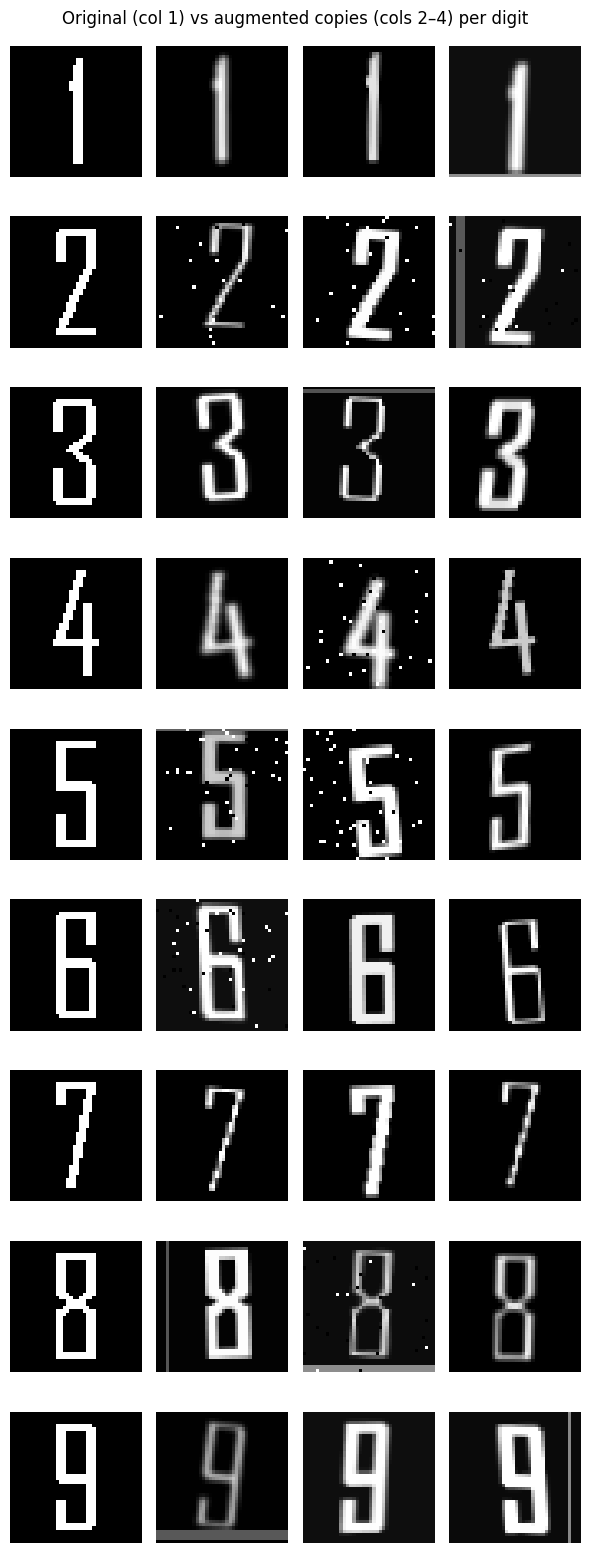

In [45]:
# Show original vs 3 augmented versions for one sample of each digit
fig, axes = plt.subplots(9, 4, figsize=(6, 16))
fig.suptitle("Original (col 1) vs augmented copies (cols 2–4) per digit", fontsize=12)

vis_rng = np.random.default_rng(seed=0)
for row, digit in enumerate(range(1, 10)):
    digit_indices = np.where(labels == digit)[0]
    idx = next((i for i in digit_indices if images[i].max() > 0), digit_indices[0])
    original = images[idx]
    axes[row, 0].imshow(original, cmap="gray", vmin=0, vmax=255)
    axes[row, 0].set_ylabel(str(digit), fontsize=11, rotation=0, labelpad=12)
    axes[row, 0].axis("off")
    for col in range(1, 4):
        axes[row, col].imshow(augment_image(original, rng=vis_rng), cmap="gray", vmin=0, vmax=255)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

## 3. Training Set Summary

The CNN is trained only on augmented Chars74K printed digits. This keeps the training distribution clean and fully controlled while still giving the model much more capacity and augmentation than the SVM.


In [46]:
print(f"Training samples used by CNN: {len(all_images):,}")
unique, counts = np.unique(all_labels, return_counts=True)
print("\nSamples per digit after augmentation:")
for d, c in zip(unique, counts):
    print(f"  Digit {d}: {c:,}")


Training samples used by CNN: 45,720

Samples per digit after augmentation:
  Digit 1: 5,080
  Digit 2: 5,080
  Digit 3: 5,080
  Digit 4: 5,080
  Digit 5: 5,080
  Digit 6: 5,080
  Digit 7: 5,080
  Digit 8: 5,080
  Digit 9: 5,080


## 4. CNN Architecture

We use a stronger 4-stage CNN than the earlier LeNet-style baseline. Each stage stacks two convolutions before pooling, which gives the network more representational power while still remaining lightweight enough for notebook training and project inference.


In [47]:
import copy
import random
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout),
        )

    def forward(self, x):
        return self.block(x)


class SudokuDigitCNN(nn.Module):
    """Stronger CNN for Sudoku digit recognition."""

    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(1, 32, dropout=0.05),     # 40 -> 20
            ConvBlock(32, 64, dropout=0.08),    # 20 -> 10
            ConvBlock(64, 128, dropout=0.10),   # 10 -> 5
            ConvBlock(128, 256, dropout=0.12),  # 5 -> 2
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 2 * 2, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.35),
            nn.Linear(256, 9),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


seed_everything(SEED)
print(SudokuDigitCNN())
total_params = sum(p.numel() for p in SudokuDigitCNN().parameters())
print(f"\nTotal parameters: {total_params:,}")


SudokuDigitCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (7): Dropout2d(p=0.05, inplace=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), paddin

## 5. PyTorch Dataset and DataLoaders

The train/validation split remains stratified, but training is now more class-aware:
- a **weighted sampler** over-emphasises harder classes during mini-batch construction
- the loss also uses **class weights** with an extra boost for digit **4**
- on-the-fly augmentation now better matches Sudoku extraction artifacts


In [48]:
class DigitDataset(Dataset):
    """Wrap numpy image arrays for PyTorch."""

    def __init__(self, images, labels, augment=False, seed=SEED, return_index=False):
        self.images = images
        self.labels = labels - 1  # digits 1-9 -> class indices 0-8
        self.augment = augment
        self.return_index = return_index
        self._rng = np.random.default_rng(seed=seed)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx].copy()
        if self.augment:
            img = augment_image(img, rng=self._rng)
        tensor = torch.from_numpy(img.astype(np.float32)).unsqueeze(0) / 255.0
        label = int(self.labels[idx])
        if self.return_index:
            return tensor, label, int(idx)
        return tensor, label


train_images, val_images, train_labels, val_labels = train_test_split(
    all_images,
    all_labels,
    test_size=0.12,
    random_state=SEED,
    stratify=all_labels,
)

train_ds = DigitDataset(train_images, train_labels, augment=True, seed=SEED)
val_ds = DigitDataset(val_images, val_labels, augment=False, seed=SEED)

train_class_counts = np.bincount(train_labels - 1, minlength=9)
train_class_boost = np.ones(9, dtype=np.float32)
train_class_boost[3] = 1.9  # digit 4 is the current bottleneck
train_sample_weights = (1.0 / np.maximum(train_class_counts[train_labels - 1], 1)).astype(np.float64)
train_sample_weights *= train_class_boost[train_labels - 1]
train_sampler = WeightedRandomSampler(
    weights=torch.as_tensor(train_sample_weights, dtype=torch.double),
    num_samples=len(train_sample_weights),
    replacement=True,
)

train_loader = DataLoader(
    train_ds,
    batch_size=128,
    sampler=train_sampler,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_ds,
    batch_size=256,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print(f"Train : {len(train_ds):,} samples")
print(f"Val   : {len(val_ds):,} samples")
print("\nTrain samples per digit:")
for digit, count in enumerate(train_class_counts, start=1):
    print(f"  Digit {digit}: {count:,}")


Train : 40,233 samples
Val   : 5,487 samples

Train samples per digit:
  Digit 1: 4,470
  Digit 2: 4,471
  Digit 3: 4,470
  Digit 4: 4,470
  Digit 5: 4,470
  Digit 6: 4,471
  Digit 7: 4,470
  Digit 8: 4,471
  Digit 9: 4,470


## 6. Training

Training now explicitly optimises for the failure modes we care about:
- **AdamW** with weight decay for stable optimisation
- **class-weighted cross-entropy** with a targeted boost for digit **4**
- **CosineAnnealingLR** for smoother late-stage refinement
- **early stopping on a recall-aware score**, not raw accuracy alone


In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
print(f"Training on: {device}")

model = SudokuDigitCNN().to(device)
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=28, eta_min=5e-6)

base_class_weights = train_class_counts.sum() / (len(train_class_counts) * np.maximum(train_class_counts, 1))
base_class_weights = np.sqrt(base_class_weights).astype(np.float32)
base_class_weights[3] *= 1.35  # extra focus on digit 4 recall
class_weights = torch.tensor(base_class_weights, dtype=torch.float32, device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.02)

EPOCHS = 50
EARLY_STOPPING_PATIENCE = 7
train_losses = []
val_accuracies = []
val_macro_recalls = []
val_digit4_recalls = []
best_score = -np.inf
best_val_acc = 0.0
best_val_macro_recall = 0.0
best_state_dict = None
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    epoch_loss = running_loss / len(train_ds)
    train_losses.append(epoch_loss)

    model.eval()
    val_true = []
    val_pred = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            preds = model(X_batch).argmax(dim=1)
            val_pred.extend(preds.cpu().numpy().tolist())
            val_true.extend(y_batch.cpu().numpy().tolist())

    val_true = np.array(val_true)
    val_pred = np.array(val_pred)
    val_acc = float((val_pred == val_true).mean())
    cm_val = confusion_matrix(val_true, val_pred, labels=list(range(9)))
    per_class_recall = np.divide(
        np.diag(cm_val),
        cm_val.sum(axis=1),
        out=np.zeros(9, dtype=np.float64),
        where=cm_val.sum(axis=1) != 0,
    )
    val_macro_recall = float(per_class_recall.mean())
    digit4_recall = float(per_class_recall[3])

    val_accuracies.append(val_acc)
    val_macro_recalls.append(val_macro_recall)
    val_digit4_recalls.append(digit4_recall)
    scheduler.step()

    selection_score = val_macro_recall + 0.20 * val_acc
    if selection_score > best_score:
        best_score = selection_score
        best_val_acc = val_acc
        best_val_macro_recall = val_macro_recall
        best_state_dict = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch {epoch:2d}/{EPOCHS}  loss={epoch_loss:.4f}  "
        f"val_acc={val_acc*100:.2f}%  macro_recall={val_macro_recall*100:.2f}%  "
        f"digit4_recall={digit4_recall*100:.2f}%  lr={current_lr:.6f}"
    )

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("Early stopping triggered.")
        break

if best_state_dict is None:
    raise RuntimeError("Training did not produce a valid checkpoint.")

model.load_state_dict(best_state_dict)
print(
    f"\nTraining complete. Best checkpoint: "
    f"val_acc={best_val_acc*100:.2f}%  macro_recall={best_val_macro_recall*100:.2f}%"
)


Training on: cuda
Epoch  1/50  loss=0.4071  val_acc=98.05%  macro_recall=98.05%  digit4_recall=99.67%  lr=0.000299
Epoch  2/50  loss=0.2108  val_acc=98.54%  macro_recall=98.54%  digit4_recall=99.18%  lr=0.000296
Epoch  3/50  loss=0.1887  val_acc=98.72%  macro_recall=98.72%  digit4_recall=99.51%  lr=0.000292
Epoch  4/50  loss=0.1830  val_acc=98.96%  macro_recall=98.96%  digit4_recall=99.51%  lr=0.000285
Epoch  5/50  loss=0.1734  val_acc=99.00%  macro_recall=99.00%  digit4_recall=99.67%  lr=0.000277
Epoch  6/50  loss=0.1666  val_acc=99.25%  macro_recall=99.25%  digit4_recall=99.67%  lr=0.000268
Epoch  7/50  loss=0.1649  val_acc=99.31%  macro_recall=99.31%  digit4_recall=99.51%  lr=0.000257
Epoch  8/50  loss=0.1603  val_acc=99.20%  macro_recall=99.20%  digit4_recall=99.34%  lr=0.000244
Epoch  9/50  loss=0.1574  val_acc=99.34%  macro_recall=99.34%  digit4_recall=99.34%  lr=0.000231
Epoch 10/50  loss=0.1553  val_acc=99.36%  macro_recall=99.36%  digit4_recall=99.34%  lr=0.000216
Epoch 11/50 

### Training Curves

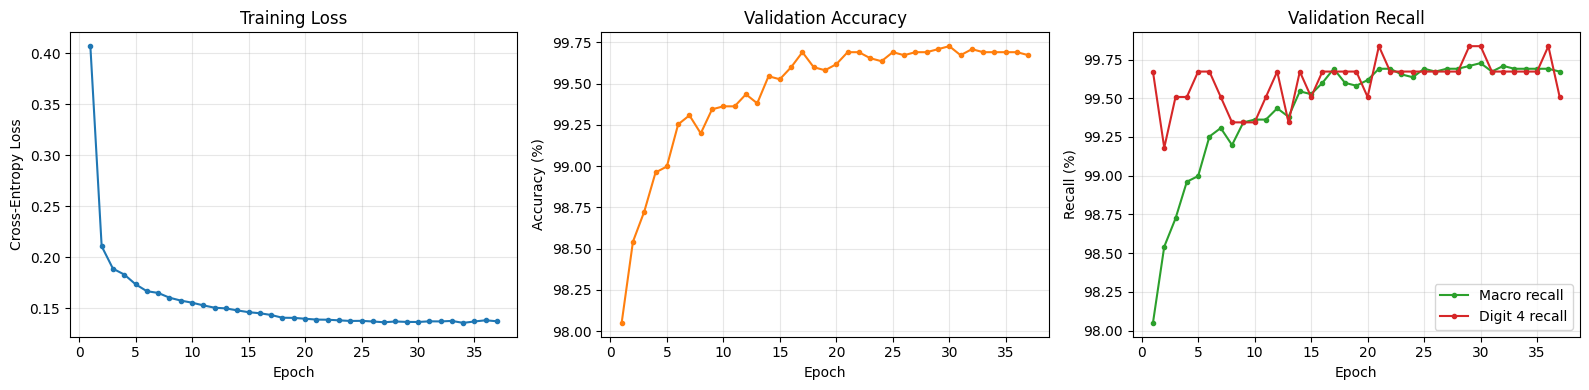

In [51]:
epochs_ran = range(1, len(train_losses) + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs_ran, train_losses, marker="o", markersize=3)
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, [a * 100 for a in val_accuracies], marker="o", markersize=3, color="tab:orange")
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_ran, [a * 100 for a in val_macro_recalls], marker="o", markersize=3, color="tab:green", label="Macro recall")
axes[2].plot(epochs_ran, [a * 100 for a in val_digit4_recalls], marker="o", markersize=3, color="tab:red", label="Digit 4 recall")
axes[2].set_title("Validation Recall")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Recall (%)")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()


## 7. Evaluation on All Sudoku Puzzles

Training is Chars74K-only, so every Sudoku puzzle can now be used as a real-world evaluation sample. This is the real measure of whether CNN digit recognition stops being the pipeline bottleneck.


In [20]:
def _normalize_cell_debug(img, canvas_size=40, padding=4):
    """
    Normalizes a digit cell image and returns intermediate stages.

    The main design goal is to preserve disconnected-but-valid digit parts
    such as the cross-stroke of many printed 4s, while still suppressing
    obvious border fragments and tiny noise.
    """
    img = img.copy()
    if img.mean() > 127:
        img = cv2.bitwise_not(img)

    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    binary = binary.astype(np.uint8)

    num_labels, labels_map, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    filtered = np.zeros_like(binary)
    component_summary = []

    if num_labels > 1:
        h, w = binary.shape
        center = np.array([w / 2.0, h / 2.0], dtype=np.float32)
        largest_area = int(stats[1:, cv2.CC_STAT_AREA].max())
        min_component_area = max(6, int(0.025 * h * w))

        for label_idx in range(1, num_labels):
            x = stats[label_idx, cv2.CC_STAT_LEFT]
            y = stats[label_idx, cv2.CC_STAT_TOP]
            comp_w = stats[label_idx, cv2.CC_STAT_WIDTH]
            comp_h = stats[label_idx, cv2.CC_STAT_HEIGHT]
            area = int(stats[label_idx, cv2.CC_STAT_AREA])
            centroid = np.array([
                x + comp_w / 2.0,
                y + comp_h / 2.0,
            ], dtype=np.float32)

            border_touch = (
                x == 0 or y == 0 or (x + comp_w) >= w or (y + comp_h) >= h
            )
            aspect_ratio = max(comp_w, comp_h) / max(1, min(comp_w, comp_h))
            dist_norm = np.linalg.norm((centroid - center) / np.array([w, h], dtype=np.float32))
            is_line_fragment = border_touch and area < 0.35 * largest_area and aspect_ratio > 6.0

            keep = (
                area >= min_component_area and
                not is_line_fragment and
                (
                    area >= 0.18 * largest_area or
                    dist_norm <= 0.33 or
                    (not border_touch and area >= 0.10 * largest_area)
                )
            )

            component_summary.append({
                "label": int(label_idx),
                "bbox": (int(x), int(y), int(comp_w), int(comp_h)),
                "area": area,
                "border_touch": bool(border_touch),
                "aspect_ratio": float(aspect_ratio),
                "distance_to_center": float(dist_norm),
                "kept": bool(keep),
            })

            if keep:
                filtered[labels_map == label_idx] = 255

        if not np.any(filtered):
            largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
            filtered = np.where(labels_map == largest, 255, 0).astype(np.uint8)
    else:
        filtered = binary.copy()

    coords = cv2.findNonZero(filtered)
    if coords is None:
        normalized = np.zeros((canvas_size, canvas_size), dtype=np.uint8)
        return {
            "input": img,
            "binary": binary,
            "filtered": filtered,
            "crop": None,
            "normalized": normalized,
            "component_summary": component_summary,
        }

    x, y, w, h = cv2.boundingRect(coords)
    digit_crop = filtered[y:y + h, x:x + w]

    inner = canvas_size - 2 * padding
    scale = inner / max(w, h)
    new_w = max(1, int(w * scale))
    new_h = max(1, int(h * scale))
    digit_resized = cv2.resize(digit_crop, (new_w, new_h), interpolation=cv2.INTER_AREA)
    _, digit_resized = cv2.threshold(digit_resized, 127, 255, cv2.THRESH_BINARY)

    canvas = np.zeros((canvas_size, canvas_size), dtype=np.uint8)
    y_off = (canvas_size - new_h) // 2
    x_off = (canvas_size - new_w) // 2
    canvas[y_off:y_off + new_h, x_off:x_off + new_w] = digit_resized

    return {
        "input": img,
        "binary": binary,
        "filtered": filtered,
        "crop": digit_crop,
        "normalized": canvas,
        "component_summary": component_summary,
    }


def normalize_cell(img, canvas_size=40, padding=4):
    """
    Normalizes a digit cell image for feature extraction and CNN training.

    Keeps multiple meaningful connected components when needed so printed 4s
    and other fragile shapes are less likely to collapse into a 1, 3, or 8.
    """
    return _normalize_cell_debug(img, canvas_size=canvas_size, padding=padding)["normalized"]



In [52]:

SUDOKU_DATASET_PATH = ensure_sudoku_dataset_available()

# Rotation fix for known mis-oriented Sudoku images
SENTINEL = os.path.join("data", "sudoku_dataset", ".rotations_applied")
ROTATIONS = {
    "image1024.jpg": cv2.ROTATE_90_COUNTERCLOCKWISE,
    "image1031.jpg": cv2.ROTATE_90_COUNTERCLOCKWISE,
    "image1036.jpg": cv2.ROTATE_90_COUNTERCLOCKWISE,
    "image1038.jpg": cv2.ROTATE_90_COUNTERCLOCKWISE,
    "image1039.jpg": cv2.ROTATE_90_COUNTERCLOCKWISE,
    "image1040.jpg": cv2.ROTATE_90_COUNTERCLOCKWISE,
    "image1041.jpg": cv2.ROTATE_90_COUNTERCLOCKWISE,
    "image1043.jpg": cv2.ROTATE_90_COUNTERCLOCKWISE,
    "image1083.jpg": cv2.ROTATE_180,
}

if os.path.exists(SENTINEL):
    print("Rotation fixes already applied, skipping.")
else:
    fixed = 0
    for fname, rotation in ROTATIONS.items():
        path = os.path.join(SUDOKU_DATASET_PATH, fname)
        if os.path.exists(path):
            img = cv2.imread(path)
            cv2.imwrite(path, cv2.rotate(img, rotation))
            print(f"Fixed: {fname}")
            fixed += 1
    open(SENTINEL, "w").close()
    print(f"\n{fixed} image(s) corrected. Sentinel written to {SENTINEL}")

test_files_eval = sorted([f for f in os.listdir(SUDOKU_DATASET_PATH) if f.endswith(".jpg")])

test_img_list = []
test_lbl_list = []
skipped_test = 0

for fname in test_files_eval:
    image_path = os.path.join(SUDOKU_DATASET_PATH, fname)
    dat_path = image_path.replace(".jpg", ".dat")
    if not os.path.exists(dat_path):
        skipped_test += 1
        continue

    cells = extract_cells_for_training(image_path, cell_size=CELL_SIZE)
    if cells is None:
        skipped_test += 1
        continue

    grid = parse_dat_file(dat_path)
    for row in range(9):
        for col in range(9):
            digit = grid[row][col]
            if digit == 0:
                continue
            cell_img = normalize_cell(cells[row * 9 + col])
            if cell_img.max() == 0:
                continue
            test_img_list.append(cell_img)
            test_lbl_list.append(digit)

test_images_eval = np.array(test_img_list, dtype=np.uint8)
test_labels_eval = np.array(test_lbl_list, dtype=np.int64)
print(f"Sudoku puzzles evaluated: {len(test_files_eval) - skipped_test}/{len(test_files_eval)}")
print(f"Cell test samples      : {len(test_images_eval):,}")


Sudoku dataset ready at: data/sudoku_dataset/images
Rotation fixes already applied, skipping.
Sudoku puzzles evaluated: 82/180
Cell test samples      : 2,374


In [53]:
test_ds = DigitDataset(test_images_eval, test_labels_eval, augment=False, return_index=True)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=0)

model.eval()
all_preds = []
all_true = []
all_confidences = []
misclassified_examples = []

with torch.no_grad():
    for X_batch, y_batch, idx_batch in test_loader:
        logits = model(X_batch.to(device))
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1).cpu().numpy()
        confs = probs.max(dim=1).values.cpu().numpy()
        true_batch = y_batch.numpy()
        idx_batch = idx_batch.numpy()

        all_preds.extend(preds.tolist())
        all_true.extend(true_batch.tolist())
        all_confidences.extend(confs.tolist())

        for pred, true, conf, idx in zip(preds, true_batch, confs, idx_batch):
            if pred != true:
                misclassified_examples.append({
                    "index": int(idx),
                    "image": test_images_eval[idx],
                    "true_digit": int(true + 1),
                    "pred_digit": int(pred + 1),
                    "confidence": float(conf),
                })

# Shift class indices (0-8) back to digit labels (1-9) for display
pred_digits = [p + 1 for p in all_preds]
true_digits = [t + 1 for t in all_true]

print(classification_report(true_digits, pred_digits, target_names=[str(d) for d in range(1, 10)]))
print(f"Misclassified cells: {len(misclassified_examples)}/{len(test_images_eval)}")

digit4_confusions = Counter(
    sample["pred_digit"] for sample in misclassified_examples if sample["true_digit"] == 4
)
print("Digit 4 confusion counts:", dict(sorted(digit4_confusions.items())))


              precision    recall  f1-score   support

           1       0.98      0.97      0.98       262
           2       1.00      0.96      0.98       258
           3       0.98      0.99      0.99       290
           4       0.98      0.98      0.98       236
           5       0.94      1.00      0.97       271
           6       0.98      0.99      0.99       267
           7       1.00      0.98      0.99       268
           8       1.00      0.99      0.99       284
           9       0.99      0.98      0.99       238

    accuracy                           0.98      2374
   macro avg       0.98      0.98      0.98      2374
weighted avg       0.98      0.98      0.98      2374

Misclassified cells: 42/2374
Digit 4 confusion counts: {1: 2, 3: 2, 9: 1}


### Confusion Matrix and Error Analysis


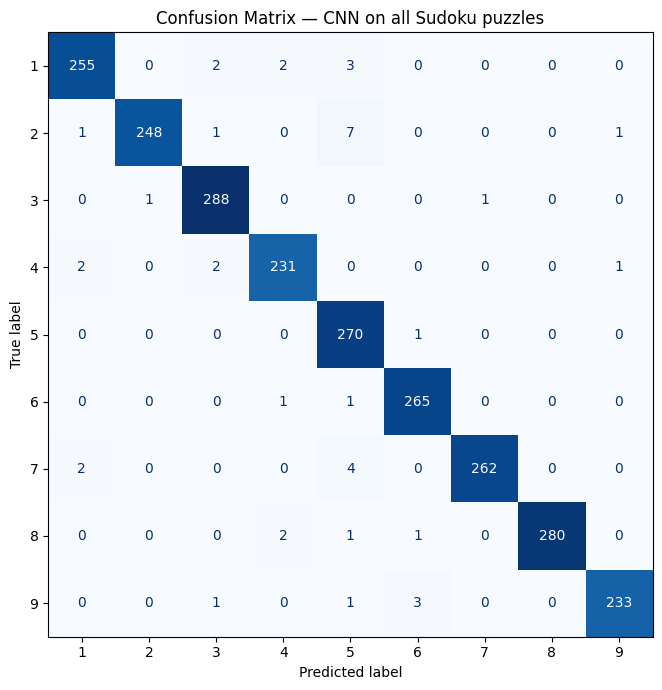

In [54]:
cm = confusion_matrix(true_digits, pred_digits)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(1, 10)))
fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — CNN on all Sudoku puzzles")
plt.tight_layout()
plt.show()


### Hard Errors

This grid prioritises the worst high-confidence mistakes, with true **4** errors shown first.


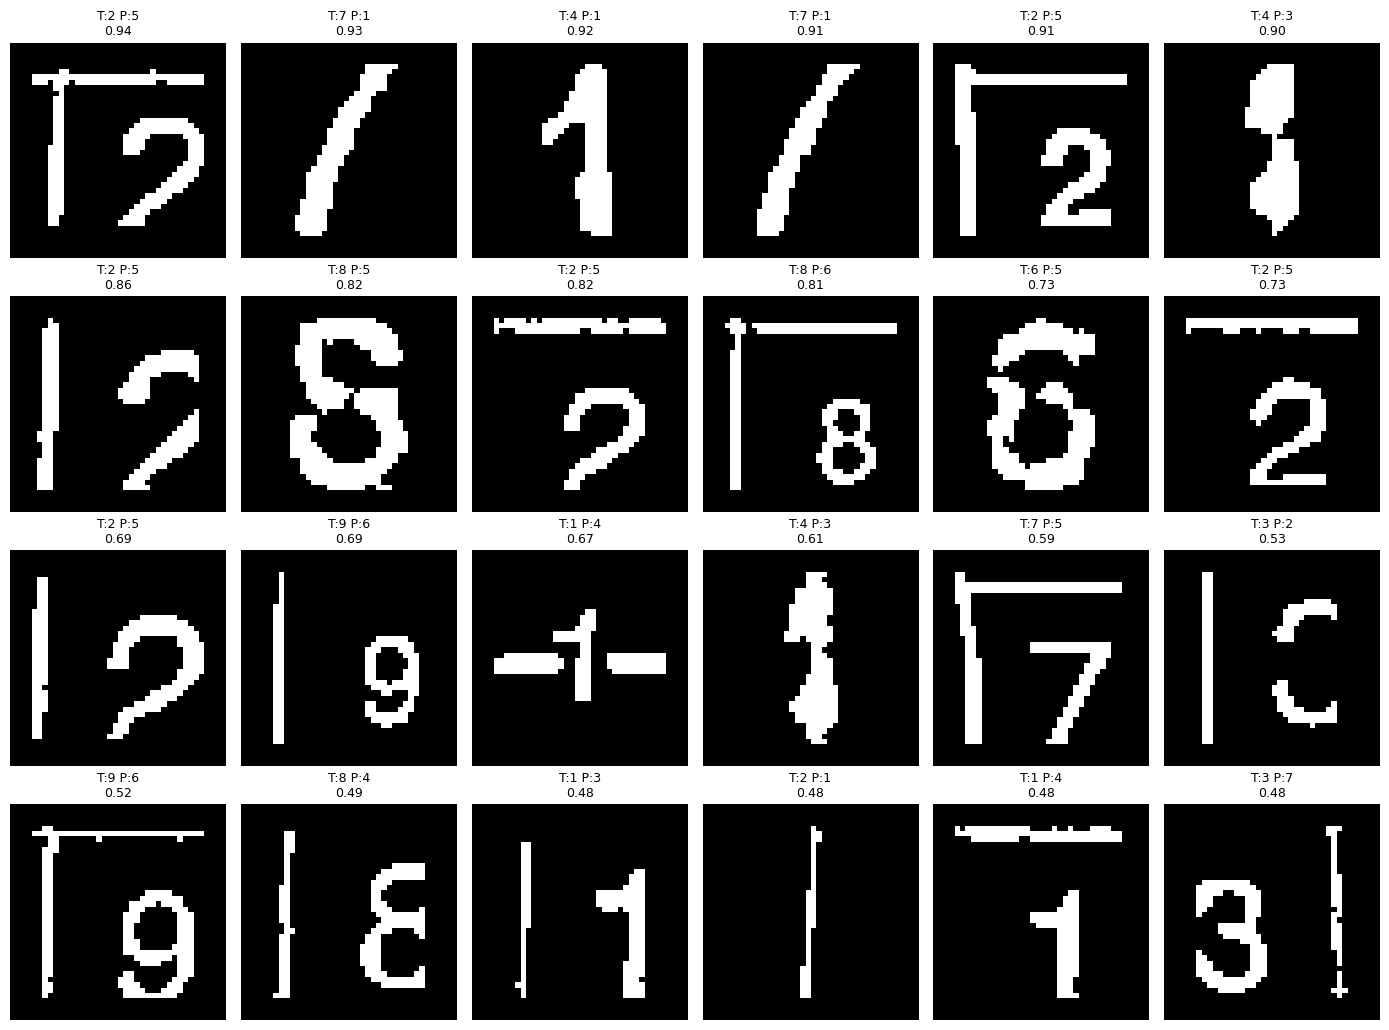

In [55]:
priority_errors = sorted(
    misclassified_examples,
    key=lambda sample: (
        # sample["true_digit"] == 4,
        sample["confidence"],
    ),
    reverse=True,
)

top_k = min(24, len(priority_errors))
if top_k == 0:
    print("No misclassified Sudoku cells to display.")
else:
    rows = int(np.ceil(top_k / 6))
    fig, axes = plt.subplots(rows, 6, figsize=(14, 2.6 * rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, sample in zip(axes, priority_errors[:top_k]):
        ax.imshow(sample["image"], cmap="gray", vmin=0, vmax=255)
        ax.set_title(
            f"T:{sample['true_digit']} P:{sample['pred_digit']}\n{sample['confidence']:.2f}",
            fontsize=9,
        )
        ax.axis("off")

    for ax in axes[top_k:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


## 8. Export Model

Save the trained model state dict to `models/digit_cnn.pth` and write `cnn_model.py` so the project can load the improved CNN architecture for inference.


In [56]:
os.makedirs("models", exist_ok=True)
torch.save(model.state_dict(), "models/digit_cnn.pth")
print("Model saved to models/digit_cnn.pth")

_cnn_module = '''\
import torch
import torch.nn as nn
import numpy as np


class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout),
        )

    def forward(self, x):
        return self.block(x)


class SudokuDigitCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(1, 32, dropout=0.05),
            ConvBlock(32, 64, dropout=0.08),
            ConvBlock(64, 128, dropout=0.10),
            ConvBlock(128, 256, dropout=0.12),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 2 * 2, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.35),
            nn.Linear(256, 9),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


def load_digit_cnn(model_path="models/digit_cnn.pth", device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = SudokuDigitCNN().to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    return model, device


def predict_digit(model, cell_img, device):
    tensor = torch.from_numpy(cell_img.astype(np.float32)).unsqueeze(0).unsqueeze(0) / 255.0
    with torch.no_grad():
        logits = model(tensor.to(device))
        probs = torch.softmax(logits, dim=1)
        idx = probs.argmax(dim=1).item()
    return idx + 1, probs[0, idx].item()
'''

with open("cnn_model.py", "w") as f:
    f.write(_cnn_module)
print("Helper module written to cnn_model.py")


Model saved to models/digit_cnn.pth
Helper module written to cnn_model.py


In [36]:
import json
import os
import subprocess

import cv2
import numpy as np
from skimage.feature import hog, local_binary_pattern

# HOG parameters — must stay consistent between training and inference
# pixels_per_cell=(4,4) gives a 10x10 cell grid on a 40x40 image,
# capturing finer local structure to distinguish similar digits (3/6/8/9)
HOG_PARAMS = dict(
    orientations=9,
    pixels_per_cell=(4, 4),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
)

# LBP parameters — captures loop/curve topology that HOG alone misses
# uniform LBP with P=8, R=1 produces 59 unique pattern bins
LBP_PARAMS = dict(P=8, R=1, method="uniform")
LBP_GRID = 4  # divide image into LBP_GRID x LBP_GRID regions for spatial encoding


def _suppress_border_lines(binary, max_border_width=4, fill_ratio_threshold=0.5):
    """
    Removes dense foreground rows/columns hugging the image border.

    This targets leftover Sudoku cell borders that survive upstream cropping.
    The cleanup is intentionally conservative and only acts near the outer edge.
    """
    cleaned = binary.copy()
    h, w = cleaned.shape

    def clear_dense_edge_rows():
        changed = False
        for offset in range(min(max_border_width, h)):
            if np.count_nonzero(cleaned[offset]) / w >= fill_ratio_threshold:
                cleaned[offset] = 0
                changed = True
            else:
                break
        for offset in range(min(max_border_width, h)):
            row = h - 1 - offset
            if np.count_nonzero(cleaned[row]) / w >= fill_ratio_threshold:
                cleaned[row] = 0
                changed = True
            else:
                break
        return changed

    def clear_dense_edge_cols():
        changed = False
        for offset in range(min(max_border_width, w)):
            if np.count_nonzero(cleaned[:, offset]) / h >= fill_ratio_threshold:
                cleaned[:, offset] = 0
                changed = True
            else:
                break
        for offset in range(min(max_border_width, w)):
            col = w - 1 - offset
            if np.count_nonzero(cleaned[:, col]) / h >= fill_ratio_threshold:
                cleaned[:, col] = 0
                changed = True
            else:
                break
        return changed

    for _ in range(max_border_width):
        changed = clear_dense_edge_rows()
        changed = clear_dense_edge_cols() or changed
        if not changed:
            break

    return cleaned


def _normalize_cell_debug(img, canvas_size=40, padding=4):
    """
    Normalizes a digit cell image and returns intermediate stages.

    The main design goal is to preserve disconnected-but-valid digit parts
    such as the cross-stroke of many printed 4s, while still suppressing
    obvious border fragments and tiny noise.
    """
    img = img.copy()
    if img.mean() > 127:
        img = cv2.bitwise_not(img)

    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    binary = binary.astype(np.uint8)
    border_cleaned = _suppress_border_lines(binary)

    num_labels, labels_map, stats, _ = cv2.connectedComponentsWithStats(border_cleaned, connectivity=8)
    filtered = np.zeros_like(binary)
    component_summary = []

    if num_labels > 1:
        h, w = border_cleaned.shape
        center = np.array([w / 2.0, h / 2.0], dtype=np.float32)
        largest_area = int(stats[1:, cv2.CC_STAT_AREA].max())
        min_component_area = max(6, int(0.025 * h * w))

        for label_idx in range(1, num_labels):
            x = stats[label_idx, cv2.CC_STAT_LEFT]
            y = stats[label_idx, cv2.CC_STAT_TOP]
            comp_w = stats[label_idx, cv2.CC_STAT_WIDTH]
            comp_h = stats[label_idx, cv2.CC_STAT_HEIGHT]
            area = int(stats[label_idx, cv2.CC_STAT_AREA])
            centroid = np.array([
                x + comp_w / 2.0,
                y + comp_h / 2.0,
            ], dtype=np.float32)

            border_touch = (
                x == 0 or y == 0 or (x + comp_w) >= w or (y + comp_h) >= h
            )
            aspect_ratio = max(comp_w, comp_h) / max(1, min(comp_w, comp_h))
            dist_norm = np.linalg.norm((centroid - center) / np.array([w, h], dtype=np.float32))
            is_line_fragment = border_touch and area < 0.35 * largest_area and aspect_ratio > 6.0

            keep = (
                area >= min_component_area and
                not is_line_fragment and
                (
                    area >= 0.18 * largest_area or
                    dist_norm <= 0.33 or
                    (not border_touch and area >= 0.10 * largest_area)
                )
            )

            component_summary.append({
                "label": int(label_idx),
                "bbox": (int(x), int(y), int(comp_w), int(comp_h)),
                "area": area,
                "border_touch": bool(border_touch),
                "aspect_ratio": float(aspect_ratio),
                "distance_to_center": float(dist_norm),
                "kept": bool(keep),
            })

            if keep:
                filtered[labels_map == label_idx] = 255

        if not np.any(filtered):
            largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
            filtered = np.where(labels_map == largest, 255, 0).astype(np.uint8)
    else:
        filtered = border_cleaned.copy()

    coords = cv2.findNonZero(filtered)
    if coords is None:
        normalized = np.zeros((canvas_size, canvas_size), dtype=np.uint8)
        return {
            "input": img,
            "binary": binary,
            "border_cleaned": border_cleaned,
            "filtered": filtered,
            "crop": None,
            "normalized": normalized,
            "component_summary": component_summary,
        }

    x, y, w, h = cv2.boundingRect(coords)
    digit_crop = filtered[y:y + h, x:x + w]

    inner = canvas_size - 2 * padding
    scale = inner / max(w, h)
    new_w = max(1, int(w * scale))
    new_h = max(1, int(h * scale))
    digit_resized = cv2.resize(digit_crop, (new_w, new_h), interpolation=cv2.INTER_AREA)
    _, digit_resized = cv2.threshold(digit_resized, 127, 255, cv2.THRESH_BINARY)

    canvas = np.zeros((canvas_size, canvas_size), dtype=np.uint8)
    y_off = (canvas_size - new_h) // 2
    x_off = (canvas_size - new_w) // 2
    canvas[y_off:y_off + new_h, x_off:x_off + new_w] = digit_resized

    return {
        "input": img,
        "binary": binary,
        "border_cleaned": border_cleaned,
        "filtered": filtered,
        "crop": digit_crop,
        "normalized": canvas,
        "component_summary": component_summary,
    }


def normalize_cell(img, canvas_size=40, padding=4):
    """
    Normalizes a digit cell image for feature extraction and CNN training.

    Keeps multiple meaningful connected components when needed so printed 4s
    and other fragile shapes are less likely to collapse into a 1, 3, or 8.
    """
    return _normalize_cell_debug(img, canvas_size=canvas_size, padding=padding)["normalized"]


def augment_image(img, rng=None):
    """
    Applies random augmentations to a normalized cell image to simulate
    scan artifacts and extraction defects seen in real Sudoku puzzle images.

    Augmentations (each applied randomly):
      - Rotation / shift      : misalignment during crop or print
      - Mild affine warp      : perspective / paper distortion
      - Erosion/dilation      : thins or thickens strokes
      - Gaussian blur         : scan softness
      - Contrast scaling      : thresholding / lighting variation
      - Grid-line remnants    : imperfect border removal
      - Salt-and-pepper noise : scan grain

    Args:
        img (np.ndarray): Normalized grayscale cell image (output of normalize_cell).
        rng (np.random.Generator, optional): Random number generator for reproducibility.

    Returns:
        np.ndarray: Augmented image of the same shape and dtype.
    """
    if rng is None:
        rng = np.random.default_rng()

    img = img.copy().astype(np.float32)

    # Random rotation and translation to simulate imperfect cropping
    angle = rng.uniform(-7, 7)
    h, w = img.shape
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    M[0, 2] += rng.uniform(-2.0, 2.0)
    M[1, 2] += rng.uniform(-2.0, 2.0)
    img = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR, borderValue=0)

    # Mild affine warp to mimic perspective / paper distortion
    if rng.random() < 0.45:
        src = np.float32([[0, 0], [w - 1, 0], [0, h - 1]])
        max_jitter = 2.0
        dst = src + rng.uniform(-max_jitter, max_jitter, size=(3, 2)).astype(np.float32)
        affine = cv2.getAffineTransform(src, dst)
        img = cv2.warpAffine(img, affine, (w, h), flags=cv2.INTER_LINEAR, borderValue=0)

    # Random erosion or dilation (ink weight variation)
    if rng.random() < 0.65:
        kernel = np.ones((2, 2), np.uint8)
        if rng.random() < 0.5:
            img = cv2.erode(img, kernel, iterations=1)
        else:
            img = cv2.dilate(img, kernel, iterations=1)

    # Gaussian blur
    if rng.random() < 0.55:
        sigma = rng.uniform(0.3, 1.0)
        img = cv2.GaussianBlur(img, (3, 3), sigmaX=sigma)

    # Contrast and intensity drift from thresholding / lighting differences
    if rng.random() < 0.7:
        alpha = rng.uniform(0.75, 1.25)
        beta = rng.uniform(-18, 18)
        img = np.clip(alpha * img + beta, 0, 255)

    # Add leftover grid-line fragments near the border, a common extraction artifact
    if rng.random() < 0.35:
        line_value = rng.uniform(80, 180)
        thickness = int(rng.integers(1, 3))
        margin = int(rng.integers(0, 4))
        side = int(rng.integers(0, 4))
        if side == 0:
            cv2.line(img, (0, margin), (w - 1, margin), line_value, thickness)
        elif side == 1:
            cv2.line(img, (0, h - 1 - margin), (w - 1, h - 1 - margin), line_value, thickness)
        elif side == 2:
            cv2.line(img, (margin, 0), (margin, h - 1), line_value, thickness)
        else:
            cv2.line(img, (w - 1 - margin, 0), (w - 1 - margin, h - 1), line_value, thickness)

    # Salt-and-pepper noise
    if rng.random() < 0.5:
        noise_level = rng.uniform(0.01, 0.05)
        img[rng.random(img.shape) < noise_level / 2] = 255
        img[rng.random(img.shape) < noise_level / 2] = 0

    return img.astype(np.uint8)


def parse_dat_file(dat_path):
    """
    Parses a Sudoku dataset .dat file and returns the 9x9 grid of digit labels.

    .dat format:
      Line 0: device name
      Line 1: image resolution/format
      Lines 2-10: 9 rows of space-separated digits (0 = empty cell)

    Args:
        dat_path (str): Path to the .dat file.

    Returns:
        list[list[int]]: 9x9 grid where 0 means empty and 1-9 are filled digits.
    """
    with open(dat_path) as f:
        lines = f.readlines()
    grid = []
    for line in lines[2:11]:
        row = [int(x) for x in line.strip().split()]
        grid.append(row)
    return grid


def ensure_sudoku_dataset_available(
    repo_url="https://github.com/wichtounet/sudoku_dataset.git",
    dataset_root=os.path.join("data", "sudoku_dataset"),
):
    """
    Ensures the Sudoku dataset repo is cloned locally and returns the images path.

    Args:
        repo_url (str): Git URL for the Sudoku dataset repository.
        dataset_root (str): Local clone destination.

    Returns:
        str: Path to the dataset ``images`` directory.

    Raises:
        RuntimeError: If cloning fails or the expected images directory is missing.
    """
    images_path = os.path.join(dataset_root, "images")
    if os.path.isdir(images_path):
        print(f"Sudoku dataset ready at: {images_path}")
        return images_path

    os.makedirs(os.path.dirname(dataset_root), exist_ok=True)

    if os.path.exists(dataset_root) and not os.path.isdir(images_path):
        raise RuntimeError(
            f"Sudoku dataset directory exists but images/ is missing: {dataset_root}"
        )

    print(f"Sudoku dataset not found. Cloning from {repo_url} ...")
    result = subprocess.run(
        ["git", "clone", "--depth", "1", repo_url, dataset_root],
        capture_output=True,
        text=True,
        check=False,
    )

    if result.returncode != 0:
        stderr = result.stderr.strip() or result.stdout.strip() or "unknown git error"
        raise RuntimeError(f"Failed to clone Sudoku dataset: {stderr}")

    if not os.path.isdir(images_path):
        raise RuntimeError(
            f"Sudoku dataset clone completed, but images/ was not found at {images_path}"
        )

    print(f"Sudoku dataset cloned to: {dataset_root}")
    return images_path


def _extract_cells_for_training_debug(image_path, cell_size=40):
    """
    Runs the training-time Sudoku cell extraction pipeline and returns
    intermediate images for debugging.

    Args:
        image_path (str): Path to a Sudoku puzzle image.
        cell_size (int): Output cell size in pixels.

    Returns:
        dict: Extraction artifacts and metadata. If grid detection fails,
              ``cells`` is None and ``grid_contour`` is None.
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return {
            "image_path": image_path,
            "original": None,
            "blurred": None,
            "thresh": None,
            "grid_contour": None,
            "contour_overlay": None,
            "ordered_corners": None,
            "warped": None,
            "warped_blur": None,
            "warped_thresh": None,
            "cells": None,
            "cell_debug": [],
            "board_size": 450,
            "cell_px": None,
            "margin": None,
            "error": f"Could not read image: {image_path}",
        }

    blurred = linear_filter(img, create_gaussian_kernel(9))
    thresh = apply_adaptive_threshold(blurred, 11, 2, is_inverse=True)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)

    grid_contour = None
    for contour in contours[:5]:
        contour = contour[:, 0, :]
        perimeter = find_arc_length(contour, is_closed=True)
        epsilon = 0.02 * perimeter
        approx = approximate_polygon(contour, epsilon, is_closed=True)

        if len(approx) == 4:
            grid_contour = approx
            break

    contour_overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    if grid_contour is None:
        return {
            "image_path": image_path,
            "original": img,
            "blurred": blurred,
            "thresh": thresh,
            "grid_contour": None,
            "contour_overlay": contour_overlay,
            "ordered_corners": None,
            "warped": None,
            "warped_blur": None,
            "warped_thresh": None,
            "cells": None,
            "cell_debug": [],
            "board_size": 450,
            "cell_px": None,
            "margin": None,
            "error": "Could not find a 4-corner Sudoku grid contour.",
        }

    cv2.drawContours(contour_overlay, [grid_contour.astype(np.int32)], -1, (0, 255, 0), 3)

    pts = grid_contour.reshape(4, 2).astype(np.float32)
    s = pts.sum(axis=1)
    diff = np.diff(pts, axis=1).flatten()
    ordered = np.array([
        pts[np.argmin(s)],
        pts[np.argmin(diff)],
        pts[np.argmax(s)],
        pts[np.argmax(diff)],
    ], dtype=np.float32)

    board_size = 450
    dst = np.array([
        [0, 0], [board_size - 1, 0],
        [board_size - 1, board_size - 1], [0, board_size - 1]
    ], dtype=np.float32)
    M = cv2.getPerspectiveTransform(ordered, dst)
    warped = cv2.warpPerspective(img, M, (board_size, board_size))

    warped_blur = linear_filter(warped, create_gaussian_kernel(5))
    warped_thresh = apply_adaptive_threshold(warped_blur, 11, 2, is_inverse=True)

    cell_px = board_size // 9
    margin = int(cell_px * 0.1)
    cells = []
    cell_debug = []
    empty_cell_count = 0
    for row in range(9):
        for col in range(9):
            raw_cell = warped_thresh[row * cell_px:(row + 1) * cell_px,
                                     col * cell_px:(col + 1) * cell_px]
            cropped_cell = raw_cell[margin:-margin, margin:-margin]
            resized_cell = cv2.resize(cropped_cell, (cell_size, cell_size))
            normalization_debug = _normalize_cell_debug(resized_cell)
            normalized_cell = normalization_debug["normalized"]
            ink_ratio = float(np.count_nonzero(resized_cell == 255) / resized_cell.size)
            is_empty = is_cell_empty(raw_cell, threshold_percent=0.07)
            normalization_failed = normalized_cell.max() == 0

            if is_empty:
                empty_cell_count += 1

            cells.append(resized_cell)
            cell_debug.append({
                "row": row,
                "col": col,
                "raw_cell": raw_cell,
                "cropped_cell": cropped_cell,
                "resized_cell": resized_cell,
                "binary_cell": normalization_debug["binary"],
                "border_cleaned_cell": normalization_debug["border_cleaned"],
                "filtered_cell": normalization_debug["filtered"],
                "normalized_cell": normalized_cell,
                "component_summary": normalization_debug["component_summary"],
                "ink_ratio": ink_ratio,
                "is_empty": is_empty,
                "normalization_failed": normalization_failed,
            })

    if empty_cell_count == 81:
        return {
            "image_path": image_path,
            "original": img,
            "blurred": blurred,
            "thresh": thresh,
            "grid_contour": grid_contour,
            "contour_overlay": contour_overlay,
            "ordered_corners": ordered,
            "warped": warped,
            "warped_blur": warped_blur,
            "warped_thresh": warped_thresh,
            "cells": None,
            "cell_debug": cell_debug,
            "board_size": board_size,
            "cell_px": cell_px,
            "margin": margin,
            "error": "Grid contour was found, but all 81 extracted cells were classified as empty.",
        }

    return {
        "image_path": image_path,
        "original": img,
        "blurred": blurred,
        "thresh": thresh,
        "grid_contour": grid_contour,
        "contour_overlay": contour_overlay,
        "ordered_corners": ordered,
        "warped": warped,
        "warped_blur": warped_blur,
        "warped_thresh": warped_thresh,
        "cells": cells,
        "cell_debug": cell_debug,
        "board_size": board_size,
        "cell_px": cell_px,
        "margin": margin,
        "error": None,
    }


def extract_cells_for_training(image_path, cell_size=40):
    """
    Minimal cell extractor for mining training data from the Sudoku dataset.
    Uses cv2 library functions only — independent of the custom pipeline in
    Image_Processing.ipynb.

    Args:
        image_path (str): Path to a Sudoku puzzle image.
        cell_size (int): Output cell size in pixels (should match CELL_SIZE in training).

    Returns:
        list[np.ndarray] | None: 81 cell images in row-major order (white digit on black
        background), or None if the grid could not be detected.
    """
    debug_data = _extract_cells_for_training_debug(image_path, cell_size=cell_size)
    return debug_data["cells"]


def show_training_cell_extraction_debug(
    image_path,
    cell_size=40,
    suspect_ink_ratio=0.02,
    detail_limit=8,
):
    """
    Displays the original Sudoku image alongside extraction intermediates and
    the 81 extracted cells used by the training pipeline.

    Cells are highlighted when normalization produced a blank result or when
    the extracted cell contains very little ink, which helps explain why some
    samples are being dropped.

    Args:
        image_path (str): Path to the Sudoku puzzle image to inspect.
        cell_size (int): Output cell size used by the extractor.
        suspect_ink_ratio (float): Cells below this ink ratio are marked as
                                   suspicious.

        detail_limit (int): Maximum number of suspicious cells to show with
                            normalization stages.

    Returns:
        dict: Debug metadata and intermediate images from the extractor.
    """
    import matplotlib.pyplot as plt

    debug_data = _extract_cells_for_training_debug(image_path, cell_size=cell_size)

    fig = plt.figure(figsize=(20, 14))
    gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 2.6])

    overview_items = [
        ("Original", debug_data["original"]),
        ("Grid contour", debug_data["contour_overlay"]),
        ("Initial threshold", debug_data["thresh"]),
        ("Warped board", debug_data["warped"]),
    ]

    for idx, (title, image) in enumerate(overview_items):
        ax = fig.add_subplot(gs[idx // 2, idx % 2])
        ax.set_title(title)
        if image is None:
            ax.text(0.5, 0.5, "Unavailable", ha="center", va="center", fontsize=12)
        elif image.ndim == 2:
            ax.imshow(image, cmap="gray", vmin=0, vmax=255)
        else:
            ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        ax.axis("off")

    cell_grid = gs[2, :].subgridspec(9, 9, wspace=0.05, hspace=0.25)
    suspicious = []
    for idx in range(81):
        cell_info = debug_data["cell_debug"][idx] if debug_data["cell_debug"] else None
        ax = fig.add_subplot(cell_grid[idx // 9, idx % 9])

        if cell_info is None:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center", fontsize=8)
            ax.axis("off")
            continue

        ax.imshow(cell_info["resized_cell"], cmap="gray", vmin=0, vmax=255)
        title = f"{cell_info['row'] + 1},{cell_info['col'] + 1}"
        is_suspicious = (
            cell_info["normalization_failed"] or
            cell_info["ink_ratio"] < suspect_ink_ratio
        )
        if is_suspicious:
            title += " !"
            suspicious.append(cell_info)
            for spine in ax.spines.values():
                spine.set_color("crimson")
                spine.set_linewidth(2)

        ax.set_title(title, fontsize=8, pad=2)
        ax.axis("off")

    if debug_data["error"] is not None:
        fig.suptitle(
            f"{image_path}\n{debug_data['error']}",
            fontsize=14,
            y=0.98,
        )
    else:
        fig.suptitle(
            f"{image_path}\nSuspicious cells: {len(suspicious)} / 81",
            fontsize=14,
            y=0.98,
        )

    plt.tight_layout()
    plt.show()

    if suspicious:
        detail_count = min(detail_limit, len(suspicious))
        fig, axes = plt.subplots(detail_count, 5, figsize=(12, 2.3 * detail_count))
        axes = np.atleast_2d(axes)

        for row_idx, cell_info in enumerate(suspicious[:detail_count]):
            stage_items = [
                ("Resized", cell_info["resized_cell"]),
                ("Binary", cell_info["binary_cell"]),
                ("Border clean", cell_info["border_cleaned_cell"]),
                ("Filtered", cell_info["filtered_cell"]),
                ("Normalized", cell_info["normalized_cell"]),
            ]
            for col_idx, (title, image) in enumerate(stage_items):
                ax = axes[row_idx, col_idx]
                ax.imshow(image, cmap="gray", vmin=0, vmax=255)
                prefix = f"r{cell_info['row'] + 1} c{cell_info['col'] + 1}"
                ax.set_title(f"{prefix}\n{title}", fontsize=9)
                ax.axis("off")

        fig.suptitle("Suspicious cell normalization stages", fontsize=13, y=1.01)
        plt.tight_layout()
        plt.show()

    if suspicious:
        print("Suspicious cells")
        for cell_info in suspicious:
            reasons = []
            if cell_info["normalization_failed"]:
                reasons.append("normalize_cell returned blank")
            if cell_info["ink_ratio"] < suspect_ink_ratio:
                reasons.append(f"low ink ratio ({cell_info['ink_ratio']:.3f})")
            print(
                f"  r{cell_info['row'] + 1} c{cell_info['col'] + 1}: "
                + ", ".join(reasons)
            )
            kept_components = sum(
                1 for component in cell_info["component_summary"] if component["kept"]
            )
            if cell_info["component_summary"]:
                print(f"    kept components: {kept_components}/{len(cell_info['component_summary'])}")
    elif debug_data["error"] is None:
        print("No suspicious cells detected by the heuristic.")

    return debug_data


class TrainingImageDebugBrowser:
    """
    Lightweight notebook-friendly browser for stepping through Sudoku dataset
    images, reusing the training-time extraction debug view and persisting
    which images have already been inspected.
    """

    def __init__(
        self,
        dataset_dir,
        history_path=None,
        cell_size=40,
        suspect_ink_ratio=0.02,
        image_extensions=(".jpg", ".jpeg", ".png", ".bmp"),
    ):
        self.dataset_dir = dataset_dir
        self.history_path = history_path or os.path.join(
            dataset_dir, ".viewed_debug_images.json"
        )
        self.cell_size = cell_size
        self.suspect_ink_ratio = suspect_ink_ratio
        self.image_extensions = tuple(ext.lower() for ext in image_extensions)
        self.image_names = sorted([
            name for name in os.listdir(dataset_dir)
            if name.lower().endswith(self.image_extensions)
        ])
        if not self.image_names:
            raise ValueError(f"No images found in dataset directory: {dataset_dir}")

        self.current_index = 0
        self.viewed = self._load_history()

    def _load_history(self):
        if not os.path.exists(self.history_path):
            return set()
        try:
            with open(self.history_path, "r", encoding="utf-8") as f:
                payload = json.load(f)
            return set(payload.get("viewed", []))
        except (json.JSONDecodeError, OSError):
            return set()

    def _save_history(self):
        payload = {
            "dataset_dir": self.dataset_dir,
            "viewed": sorted(self.viewed),
        }
        with open(self.history_path, "w", encoding="utf-8") as f:
            json.dump(payload, f, indent=2)

    def _resolve_index(self, index=None, image_name=None):
        if image_name is not None:
            if image_name not in self.image_names:
                raise ValueError(f"Image not found in dataset: {image_name}")
            return self.image_names.index(image_name)
        if index is None:
            return self.current_index
        if not 0 <= index < len(self.image_names):
            raise IndexError(f"Index {index} is out of range for {len(self.image_names)} images.")
        return index

    def _print_status(self):
        current_name = self.image_names[self.current_index]
        viewed_count = len(self.viewed)
        total = len(self.image_names)
        unseen_indices = [
            idx for idx, name in enumerate(self.image_names)
            if name not in self.viewed
        ]
        next_unseen = unseen_indices[0] if unseen_indices else None

        print(
            f"Current: [{self.current_index}] {current_name}\n"
            f"Viewed: {viewed_count}/{total}\n"
            f"History: {self.history_path}"
        )
        if next_unseen is not None:
            print(f"Next unseen: [{next_unseen}] {self.image_names[next_unseen]}")
        else:
            print("Next unseen: none")

    def list_images(self, start=None, limit=20, only_unseen=False):
        """
        Prints a compact window of dataset images with seen/unseen markers.
        """
        if start is None:
            start = max(0, self.current_index - limit // 2)

        end = min(len(self.image_names), start + limit)
        for idx in range(start, end):
            name = self.image_names[idx]
            if only_unseen and name in self.viewed:
                continue
            marker = "x" if name in self.viewed else " "
            current = ">" if idx == self.current_index else " "
            print(f"{current} [{idx:04d}] [{marker}] {name}")

    def show(self, index=None, image_name=None, mark_viewed=True):
        """
        Shows the selected image with extraction debug output.
        """
        resolved_index = self._resolve_index(index=index, image_name=image_name)
        self.current_index = resolved_index
        image_name = self.image_names[resolved_index]
        image_path = os.path.join(self.dataset_dir, image_name)

        debug_data = show_training_cell_extraction_debug(
            image_path,
            cell_size=self.cell_size,
            suspect_ink_ratio=self.suspect_ink_ratio,
        )

        if mark_viewed:
            self.viewed.add(image_name)
            self._save_history()

        self._print_status()
        return debug_data

    def next(self, step=1):
        return self.show(index=min(self.current_index + step, len(self.image_names) - 1))

    def prev(self, step=1):
        return self.show(index=max(self.current_index - step, 0))

    def next_unseen(self):
        for idx in range(self.current_index + 1, len(self.image_names)):
            if self.image_names[idx] not in self.viewed:
                return self.show(index=idx)
        for idx in range(0, self.current_index + 1):
            if self.image_names[idx] not in self.viewed:
                return self.show(index=idx)
        print("All dataset images have been viewed.")
        return None

    def random_unseen(self, rng=None):
        unseen = [name for name in self.image_names if name not in self.viewed]
        if not unseen:
            print("All dataset images have been viewed.")
            return None
        if rng is None:
            rng = np.random.default_rng()
        image_name = unseen[int(rng.integers(0, len(unseen)))]
        return self.show(image_name=image_name)

    def mark_unviewed(self, index=None, image_name=None):
        resolved_index = self._resolve_index(index=index, image_name=image_name)
        image_name = self.image_names[resolved_index]
        self.viewed.discard(image_name)
        self._save_history()
        print(f"Marked unviewed: [{resolved_index}] {image_name}")

    def reset_history(self):
        self.viewed.clear()
        self._save_history()
        print(f"Cleared viewed history: {self.history_path}")


def extract_hog_features(imgs):
    """
    Extracts HOG feature vectors from an array of grayscale images.

    Args:
        imgs (np.ndarray): Array of grayscale images, shape (N, H, W).

    Returns:
        np.ndarray: Feature matrix of shape (N, num_hog_features).
    """
    features = []
    for img in imgs:
        img_norm = img.astype(np.float32) / 255.0
        feat = hog(img_norm, **HOG_PARAMS)
        features.append(feat)
    return np.array(features)


def extract_lbp_features(imgs):
    """
    Extracts spatially-encoded LBP (Local Binary Pattern) feature vectors.

    The image is divided into a LBP_GRID x LBP_GRID grid of regions. A
    normalised histogram of uniform LBP codes is computed per region and
    concatenated, giving spatial awareness alongside texture information.

    LBP captures loop/curve topology (closed vs open contours) that helps
    distinguish visually similar digits such as 3, 6, 8, and 9.

    Args:
        imgs (np.ndarray): Array of grayscale images, shape (N, H, W).

    Returns:
        np.ndarray: Feature matrix of shape (N, LBP_GRID * LBP_GRID * n_bins).
    """
    n_bins = LBP_PARAMS["P"] * (LBP_PARAMS["P"] - 1) + 3  # uniform LBP bin count
    features = []
    for img in imgs:
        lbp = local_binary_pattern(img.astype(np.uint8), **LBP_PARAMS)
        h, w = img.shape
        region_h = h // LBP_GRID
        region_w = w // LBP_GRID
        hist_features = []
        for i in range(LBP_GRID):
            for j in range(LBP_GRID):
                region = lbp[i * region_h:(i + 1) * region_h,
                             j * region_w:(j + 1) * region_w]
                hist, _ = np.histogram(region, bins=n_bins,
                                       range=(0, n_bins), density=True)
                hist_features.append(hist)
        features.append(np.concatenate(hist_features))
    return np.array(features)


def extract_features(imgs):
    """
    Extracts combined HOG + LBP feature vectors for digit classification.

    HOG captures edge/gradient structure (shape of the digit).
    LBP captures local texture topology (open vs closed loops).
    Together they are more discriminative for visually similar digits.

    Feature vector size:
      HOG : 9 * 9 * 2 * 2 * 9  = 2,916  (4x4 pixels/cell, 40x40 image)
      LBP : 4 * 4 * 59          =   944
      Total                     = 3,860

    Args:
        imgs (np.ndarray): Array of grayscale images, shape (N, H, W).

    Returns:
        np.ndarray: Feature matrix of shape (N, 3860).
    """
    return np.concatenate([extract_hog_features(imgs),
                           extract_lbp_features(imgs)], axis=1)
